# 🏥 PulseMetrics-Q — Hospital Chain Quarterly Analytics

> **A pan-India hospital chain performance intelligence project using Python, EDA, and Data Visualization**

---

## 📌 Project Overview

PulseMetrics-Q is a portfolio-grade healthcare analytics project simulating the quarterly performance reporting of a 25-branch hospital chain across India.

The project covers the full analytics workflow:
- **Data Engineering** — generating realistic, messy, large-scale datasets
- **Data Quality Audit** — detecting and fixing clinical data anomalies
- **Exploratory Data Analysis** — across 8 business domains
- **Insight Delivery** — actionable findings with visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os # for file and directory path handling

## Step 1: Data Loading

In [3]:
path = r"C:\Users\kitus\Desktop\Personal Projects\5. PulseMetric Hospital EDA using Python\2. Rawdata/"

dim_doctors = pd.read_csv(path + 'dim_doctors.csv')
dim_hospitals = pd.read_csv(path + 'dim_hospitals.csv')
dim_icd_codes = pd.read_csv(path + 'dim_icd_codes.csv')
dim_patients = pd.read_csv(path + 'dim_patients.csv')
fact_admissions = pd.read_csv(path + 'fact_admissions.csv',parse_dates=['admission_date', 'discharge_date'])
fact_billing = pd.read_csv(path + 'fact_billing.csv',parse_dates=['billing_date'])
fact_lab_orders = pd.read_csv(path + 'fact_lab_orders.csv',parse_dates=['order_datetime', 'sample_collected_dt', 'report_delivered_dt'])
fact_patient_feedback = pd.read_csv(path + 'fact_patient_feedback.csv',parse_dates=['survey_date'])
fact_pharmacy_orders = pd.read_csv(path + 'fact_pharmacy_orders.csv',parse_dates=['order_date', 'dispensed_date', 'expiry_date'])

print("All 9 datasets loaded successfully!")

All 9 datasets loaded successfully!


In [4]:
class HospitalData:
    def __init__(self):
        # 1. Store all hospital-related DataFrames as class attributes
        self.dim_doctors = dim_doctors
        self.dim_hospitals = dim_hospitals
        self.dim_icd_codes = dim_icd_codes
        self.dim_patients = dim_patients
        self.fact_admissions = fact_admissions
        self.fact_billing = fact_billing
        self.fact_lab_orders = fact_lab_orders
        self.fact_patient_feedback = fact_patient_feedback
        self.fact_pharmacy_orders = fact_pharmacy_orders
        
    @property
    def list(self):
        # 2. Return the names of all loaded tables
        return [attr for attr in vars(self)]

    @property
    def columns(self):
        # 3. Display column names for each table
        for name in self.list:
            df = getattr(self, name)
            print(f"\n Table: {name}")
            print(f"Columns: {list(df.columns)}")
            print("-" * 50)

# Initialize the HospitalData object for centralized table access
tables = HospitalData()

In [5]:
tables.columns


 Table: dim_doctors
Columns: ['doctor_id', 'doctor_name', 'specialization', 'department', 'hospital_id', 'qualification', 'experience_years', 'consultation_fee', 'employment_type']
--------------------------------------------------

 Table: dim_hospitals
Columns: ['hospital_id', 'hospital_name', 'city', 'state', 'region', 'tier', 'bed_capacity', 'established_year', 'accreditation']
--------------------------------------------------

 Table: dim_icd_codes
Columns: ['icd_code', 'diagnosis_name', 'category', 'severity_level', 'is_chronic']
--------------------------------------------------

 Table: dim_patients
Columns: ['patient_id', 'patient_name', 'age', 'gender', 'blood_group', 'city_of_residence', 'state_of_residence', 'patient_type', 'referral_source', 'insurance_type', 'registration_date']
--------------------------------------------------

 Table: fact_admissions
Columns: ['admission_id', 'patient_id', 'doctor_id', 'hospital_id', 'icd_code', 'admission_date', 'discharge_date', 'a

## Step 2: Data Cleaning

### Dim Table Data cleaning

In [6]:
# 1. Table cleaning: Doctors

dim_doctors.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   doctor_id         800 non-null    str  
 1   doctor_name       800 non-null    str  
 2   specialization    800 non-null    str  
 3   department        800 non-null    str  
 4   hospital_id       800 non-null    int64
 5   qualification     800 non-null    str  
 6   experience_years  800 non-null    int64
 7   consultation_fee  800 non-null    int64
 8   employment_type   800 non-null    str  
dtypes: int64(3), str(6)
memory usage: 56.4 KB


In [7]:
dim_doctors.describe()

,hospital_id,experience_years,consultation_fee
count,800.000000,800.00000,800.000000
mean,13.160000,18.46625,1089.125000
std,7.117776,9.77360,480.320329
min,1.000000,2.00000,500.000000
25%,7.000000,9.75000,700.000000
50%,13.000000,19.00000,1000.000000
75%,19.000000,27.00000,1500.000000
max,25.000000,35.00000,2000.000000


In [8]:
dim_doctors.head()

,doctor_id,doctor_name,specialization,department,hospital_id,qualification,experience_years,consultation_fee,employment_type
0,D-0001,Dr. Anil Kumar,Oncology,Cancer Care,7,DM,8,800,Full-time
1,D-0002,Dr. Lakshmi Mishra,Anesthesiology,Critical Care,16,MD,18,1500,Consultant
2,D-0003,Dr. Vijay Iyer,Pediatrics,Women & Child,16,MD,15,700,Full-time
3,D-0004,Dr. Lakshmi Rao,General Surgery,Surgery,21,MS,30,1500,Full-time
4,D-0005,Dr. Nandita Mishra,Pulmonology,Respiratory,10,MD,16,1000,Consultant


In [9]:
# Data types are appropriate and no missing values are present in the Doctors table

In [10]:
# 2. Table cleaning: Hospitals

dim_hospitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   hospital_id       25 non-null     int64
 1   hospital_name     25 non-null     str  
 2   city              25 non-null     str  
 3   state             25 non-null     str  
 4   region            25 non-null     str  
 5   tier              25 non-null     str  
 6   bed_capacity      25 non-null     int64
 7   established_year  25 non-null     int64
 8   accreditation     9 non-null      str  
dtypes: int64(3), str(6)
memory usage: 1.9 KB


In [11]:
dim_hospitals.describe()

,hospital_id,bed_capacity,established_year
count,25.000000,25.000000,25.000000
mean,13.000000,341.200000,2013.240000
std,7.359801,193.079647,6.193276
min,1.000000,150.000000,2001.000000
25%,7.000000,200.000000,2009.000000
50%,13.000000,260.000000,2015.000000
75%,19.000000,450.000000,2018.000000
max,25.000000,800.000000,2022.000000


In [12]:
dim_hospitals.head(10)

,hospital_id,hospital_name,city,state,region,tier,bed_capacity,established_year,accreditation
0,1,PulseMetrics Hospital Bengaluru,Bengaluru,Karnataka,South,Tier-1,650,2005,NABH
1,2,PulseMetrics Hospital Mumbai,Mumbai,Maharashtra,West,Tier-1,800,2002,JCI
2,3,PulseMetrics Hospital Delhi,Delhi,Delhi,North,Tier-1,720,2001,NABH
3,4,PulseMetrics Hospital Chennai,Chennai,Tamil Nadu,South,Tier-1,600,2006,NABH
4,5,PulseMetrics Hospital Hyderabad,Hyderabad,Telangana,South,Tier-1,580,2008,NABH
5,6,PulseMetrics Hospital Pune,Pune,Maharashtra,West,Tier-1,450,2010,NABH
6,7,PulseMetrics Hospital Kolkata,Kolkata,West Bengal,East,Tier-1,500,2004,NABH
7,8,PulseMetrics Hospital Ahmedabad,Ahmedabad,Gujarat,West,Tier-1,420,2009,NaN
8,9,PulseMetrics Hospital Jaipur,Jaipur,Rajasthan,North,Tier-2,320,2012,NaN
9,10,PulseMetrics Hospital Lucknow,Lucknow,Uttar Pradesh,North,Tier-2,300,2013,NaN


In [13]:
dim_hospitals['region'].unique()

<StringArray>
['South', 'West', 'North', 'East']
Length: 4, dtype: str

In [14]:
dim_hospitals['state'].unique()

<StringArray>
[     'Karnataka',    'Maharashtra',          'Delhi',     'Tamil Nadu',
      'Telangana',    'West Bengal',        'Gujarat',      'Rajasthan',
  'Uttar Pradesh',         'Odisha',         'Punjab',         'Kerala',
 'Madhya Pradesh', 'Andhra Pradesh',          'Bihar',          'Assam',
    'Uttarakhand',      'Jharkhand']
Length: 18, dtype: str

In [15]:
dim_hospitals['city'].unique()

<StringArray>
[         'Bengaluru',             'Mumbai',              'Delhi',
            'Chennai',          'Hyderabad',               'Pune',
            'Kolkata',          'Ahmedabad',             'Jaipur',
            'Lucknow',        'Bhubaneswar',         'Chandigarh',
              'Kochi',             'Indore',             'Nagpur',
         'Coimbatore',      'Visakhapatnam',              'Patna',
           'Guwahati', 'Thiruvananthapuram',              'Surat',
           'Vadodara',             'Bhopal',           'Dehradun',
             'Ranchi']
Length: 25, dtype: str

In [16]:
# No obvious structural or categorical inconsistencies were identified in the Hospitals table

In [17]:
# 3. Table cleaning: ICD Code

dim_icd_codes.info()

<class 'pandas.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   icd_code        57 non-null     str  
 1   diagnosis_name  57 non-null     str  
 2   category        57 non-null     str  
 3   severity_level  57 non-null     str  
 4   is_chronic      57 non-null     bool 
dtypes: bool(1), str(4)
memory usage: 2.0 KB


In [18]:
dim_icd_codes.head()

,icd_code,diagnosis_name,category,severity_level,is_chronic
0,I21.0,Acute Myocardial Infarction,Cardiovascular,Critical,True
1,I10,Essential Hypertension,Cardiovascular,Moderate,True
2,I50.0,Congestive Heart Failure,Cardiovascular,Severe,True
3,I48,Atrial Fibrillation,Cardiovascular,Moderate,True
4,I25,Chronic Ischaemic Heart Disease,Cardiovascular,Severe,True


In [19]:
dim_icd_codes['category'].unique()

<StringArray>
[  'Cardiovascular',      'Respiratory',        'Endocrine',
 'Gastroenterology',            'Renal',        'Neurology',
         'Oncology',      'Orthopedics',       'Gynecology',
       'Pediatrics',       'Infectious',       'Psychiatry']
Length: 12, dtype: str

In [20]:
dim_icd_codes['severity_level'].unique()

<StringArray>
['Critical', 'Moderate', 'Severe', 'Minor']
Length: 4, dtype: str

In [21]:
# The ICD table contains complete records with appropriate data types; no cleaning was required

In [22]:
# 4. Table cleaning: Patients

dim_patients.info()

<class 'pandas.DataFrame'>
RangeIndex: 60300 entries, 0 to 60299
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   patient_id          60300 non-null  str  
 1   patient_name        60300 non-null  str  
 2   age                 60300 non-null  int64
 3   gender              60300 non-null  str  
 4   blood_group         60300 non-null  str  
 5   city_of_residence   60300 non-null  str  
 6   state_of_residence  60300 non-null  str  
 7   patient_type        60300 non-null  str  
 8   referral_source     60300 non-null  str  
 9   insurance_type      60300 non-null  str  
 10  registration_date   60300 non-null  str  
dtypes: int64(1), str(10)
memory usage: 5.1 MB


In [23]:
dim_patients.describe()

,age
count,60300.000000
mean,43.384610
std,23.630685
min,-1.000000
25%,26.000000
50%,45.000000
75%,60.000000
max,130.000000


In [24]:
dim_patients.tail()

,patient_id,patient_name,age,gender,blood_group,city_of_residence,state_of_residence,patient_type,referral_source,insurance_type,registration_date
60295,P-060295,L@ishram Sahoo,10,Male,O-,Kochi,Kerala,New,Doctor Referral,Self-Pay,2023-08-04
60296,P-060296,Adity@ Konyak,56,Female,O-,Kochi,Kerala,New,Insurance,Cashless,2024-10-07
60297,P-060297,M@nasa Mohanty,24,Female,O-,Guwahati,Assam,Repeat,Walk-in,Government,2024-06-29
60298,P-060298,Angel@ Thakur,24,Male,A+,Pune,Maharashtra,New,Online,Self-Pay,2024-09-20
60299,P-060299,P@llavi Grewal,52,Female,AB-,Guwahati,Assam,New,Walk-in,Self-Pay,2024-10-13


In [25]:
# Removing negative age entries completely

invalid_age = dim_patients[dim_patients['age'] < 0]
invalid_age.count()

patient_id            108
patient_name          108
age                   108
gender                108
blood_group           108
city_of_residence     108
state_of_residence    108
patient_type          108
referral_source       108
insurance_type        108
registration_date     108
dtype: int64

In [26]:
dim_patients = dim_patients[dim_patients['age'] >= 0]
dim_patients.info()

<class 'pandas.DataFrame'>
Index: 60192 entries, 0 to 60299
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   patient_id          60192 non-null  str  
 1   patient_name        60192 non-null  str  
 2   age                 60192 non-null  int64
 3   gender              60192 non-null  str  
 4   blood_group         60192 non-null  str  
 5   city_of_residence   60192 non-null  str  
 6   state_of_residence  60192 non-null  str  
 7   patient_type        60192 non-null  str  
 8   referral_source     60192 non-null  str  
 9   insurance_type      60192 non-null  str  
 10  registration_date   60192 non-null  str  
dtypes: int64(1), str(10)
memory usage: 5.5 MB


In [27]:
# Special character ('@') occurrences were identified in patient names and corrected to 'A'.

dim_patients['patient_name'] = dim_patients['patient_name'].str.replace('@', 'a', regex=False)

In [28]:
dim_patients['gender'].unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [29]:
dim_patients['blood_group'].unique()

<StringArray>
['AB-', 'A-', 'B+', 'B-', 'O+', 'AB+', 'O-', 'A+']
Length: 8, dtype: str

In [30]:
sorted(dim_patients['state_of_residence'].unique())

['Andhra Pradesh',
 'Assam',
 'Bihar',
 'Delhi',
 'Gujarat',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Madhya Pradesh',
 'Maharashtra',
 'Odisha',
 'Punjab',
 'Rajasthan',
 'Tamil Nadu',
 'Telangana',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

In [31]:
dim_patients['patient_type'].unique()

<StringArray>
['New', 'Repeat']
Length: 2, dtype: str

In [32]:
dim_patients['referral_source'].unique()

<StringArray>
['Corporate', 'Online', 'Insurance', 'Doctor Referral', 'Walk-in']
Length: 5, dtype: str

In [33]:
dim_patients['insurance_type'].unique()

<StringArray>
['Corporate TPA', 'Self-Pay', 'Cashless', 'Reimbursement', 'Government']
Length: 5, dtype: str

In [34]:
dim_patients['registration_date'] = pd.to_datetime(dim_patients['registration_date'])

In [35]:
dim_patients.info()

<class 'pandas.DataFrame'>
Index: 60192 entries, 0 to 60299
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   patient_id          60192 non-null  str           
 1   patient_name        60192 non-null  str           
 2   age                 60192 non-null  int64         
 3   gender              60192 non-null  str           
 4   blood_group         60192 non-null  str           
 5   city_of_residence   60192 non-null  str           
 6   state_of_residence  60192 non-null  str           
 7   patient_type        60192 non-null  str           
 8   referral_source     60192 non-null  str           
 9   insurance_type      60192 non-null  str           
 10  registration_date   60192 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(9)
memory usage: 5.5 MB


In [36]:
dim_patients[dim_patients['patient_id'].duplicated(keep = False)]

,patient_id,patient_name,age,gender,blood_group,city_of_residence,state_of_residence,patient_type,referral_source,insurance_type,registration_date
59999,P-060000,Ipsita Kadian,41,Male,A-,Mumbai,Maharashtra,New,Walk-in,Self-Pay,2023-12-24
60000,P-060000,Sandeep Murthy,72,Female,B-,Kochi,Kerala,Repeat,Walk-in,Corporate TPA,2024-01-14


In [37]:
duplicate_patients = dim_patients.drop(columns=['patient_id']).duplicated(keep=False)

dim_patients[duplicate_patients].sort_values(by=['patient_name', 'age'])

,patient_id,patient_name,age,gender,blood_group,city_of_residence,state_of_residence,patient_type,referral_source,insurance_type,registration_date
4295,P-004296,Aadhavan Shinde,0,Female,B+,Dehradun,Uttarakhand,New,Doctor Referral,Cashless,2023-06-08
60269,P-060269,Aadhavan Shinde,0,Female,B+,Dehradun,Uttarakhand,New,Doctor Referral,Cashless,2023-06-08
4953,P-004954,Aakash Krishnan,8,Female,O+,Hyderabad,Telangana,Repeat,Doctor Referral,Corporate TPA,2024-01-16
60107,P-060107,Aakash Krishnan,8,Female,O+,Hyderabad,Telangana,Repeat,Doctor Referral,Corporate TPA,2024-01-16
39805,P-039806,Aarav Jain,0,Male,A+,Nagpur,Maharashtra,New,Online,Self-Pay,2024-08-20
...,...,...,...,...,...,...,...,...,...,...,...
60180,P-060180,Yashwanth Das,48,Male,O-,Lucknow,Uttar Pradesh,New,Walk-in,Cashless,2024-01-26
21490,P-021491,Yashwanth Kadam,1,Female,B+,Coimbatore,Tamil Nadu,New,Doctor Referral,Cashless,2023-03-30
60231,P-060231,Yashwanth Kadam,1,Female,B+,Coimbatore,Tamil Nadu,New,Doctor Referral,Cashless,2023-03-30
18906,P-018907,Yashwanth Thangjam,1,Male,B+,Guwahati,Assam,Repeat,Online,Self-Pay,2023-10-23


In [38]:
# 2 records found to be duplicated using patient_id column
# 576 records found to be duplicated except patient_id column
# ------------------------------------------------------------
# Total 578 records are duplicated so we need to keep the first entries in the record and remove others.

In [39]:
# For duplicate patient_id P-060000 we need to assign a new id to the last patient (Lakshmi Kulkarni).

dim_patients.at[59999, 'patient_id'] = 'P-060300'

In [40]:
# Verify the fix
dim_patients.loc[[59999, 60000]]

,patient_id,patient_name,age,gender,blood_group,city_of_residence,state_of_residence,patient_type,referral_source,insurance_type,registration_date
59999,P-060300,Ipsita Kadian,41,Male,A-,Mumbai,Maharashtra,New,Walk-in,Self-Pay,2023-12-24
60000,P-060000,Sandeep Murthy,72,Female,B-,Kochi,Kerala,Repeat,Walk-in,Corporate TPA,2024-01-14


In [41]:
# For 576 records we just need to keep the first records.

dim_patients = dim_patients.drop_duplicates(subset=dim_patients.columns.drop('patient_id'), keep='first')

In [42]:
dim_patients.info()

<class 'pandas.DataFrame'>
Index: 59906 entries, 0 to 60288
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   patient_id          59906 non-null  str           
 1   patient_name        59906 non-null  str           
 2   age                 59906 non-null  int64         
 3   gender              59906 non-null  str           
 4   blood_group         59906 non-null  str           
 5   city_of_residence   59906 non-null  str           
 6   state_of_residence  59906 non-null  str           
 7   patient_type        59906 non-null  str           
 8   referral_source     59906 non-null  str           
 9   insurance_type      59906 non-null  str           
 10  registration_date   59906 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(9)
memory usage: 5.5 MB


In [43]:
# Negative age values were identified (111 entires) and removed.
# Converted registration_date from object to datetime64 to enable date-based analysis.
# Special character ('@') occurrences were identified in patient names and corrected to 'A'.
# Manually resolved a patient ID collision by assigning a unique ID ('P-060300') to separate distinct patients.
# Removed 288 data-entry duplicate records across all clinical fields while ignoring the 'patient_id' column.

### Fact Table Data Cleaning

In [44]:
# 5. Fact table data cleaning - Admissions

fact_admissions.info()

<class 'pandas.DataFrame'>
RangeIndex: 120600 entries, 0 to 120599
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   admission_id      120600 non-null  str           
 1   patient_id        120600 non-null  str           
 2   doctor_id         120600 non-null  str           
 3   hospital_id       120600 non-null  int64         
 4   icd_code          120600 non-null  str           
 5   admission_date    120600 non-null  datetime64[us]
 6   discharge_date    120600 non-null  datetime64[us]
 7   admission_type    120600 non-null  str           
 8   ward_type         120600 non-null  str           
 9   department        120600 non-null  str           
 10  bed_id            116977 non-null  str           
 11  length_of_stay    120600 non-null  int64         
 12  discharge_type    120600 non-null  str           
 13  readmission_flag  120600 non-null  bool          
 14  quarter        

In [45]:
fact_admissions.head(10)

,admission_id,patient_id,doctor_id,hospital_id,icd_code,admission_date,discharge_date,admission_type,ward_type,department,bed_id,length_of_stay,discharge_type,readmission_flag,quarter,fiscal_year
0,ADM-0000001,P-022109,D-0518,3,J06,2024-03-09,2024-03-10,Day-care,General,Women & Child,NaN,1,Recovered,False,Q1,FY2024-25
1,ADM-0000002,P-029984,D-0011,1,I25,2024-01-05,2024-01-11,Emergency,Private,Emergency & Trauma,BED-0315,6,Recovered,False,Q1,FY2024-25
2,ADM-0000003,P-009734,D-0039,4,F10,2024-12-18,2025-01-09,Elective,General,Neurosciences,BED-0309,22,LAMA,True,Q4,FY2024-25
3,ADM-0000004,P-021062,D-0682,7,K74,2024-05-19,2024-05-20,Day-care,General,Diagnostics,BED-0007,1,LAMA,False,Q2,FY2024-25
4,ADM-0000005,P-036902,D-0604,4,C50,2024-06-10,2024-06-27,Elective,ICU,Cancer Care,BED-0349,17,Recovered,False,Q2,FY2024-25
5,ADM-0000006,P-008291,D-0270,13,K80,2024-08-31,2024-09-04,Emergency,Semi-Private,Digestive Health,BED-0498,4,Recovered,False,Q3,FY2024-25
6,ADM-0000007,P-056195,D-0122,2,F32,2024-12-12,2024-12-10,Elective,Private,Neurosciences,BED-0388,11,Referred,False,Q4,FY2024-25
7,ADM-0000008,P-018139,D-0424,2,I50.0,2024-05-12,2024-05-13,Elective,ICU,ENT,BED-0123,1,Recovered,False,Q2,FY2024-25
8,ADM-0000009,P-036916,D-0303,8,N91,2024-04-11,2024-04-12,Elective,Semi-Private,Women & Child,BED-0139,1,Recovered,False,Q2,FY2024-25
9,ADM-0000010,P-003686,D-0002,16,N17,2024-07-13,2024-07-14,Day-care,ICU,Renal Sciences,BED-0337,1,Recovered,False,Q3,FY2024-25


In [46]:
fact_admissions['admission_type'].unique()

<StringArray>
['Day-care', 'Emergency', 'Elective']
Length: 3, dtype: str

In [47]:
fact_admissions['ward_type'].unique()

<StringArray>
['General', 'Private', 'ICU', 'Semi-Private']
Length: 4, dtype: str

In [48]:
sorted(fact_admissions['department'].unique())

['Bone & Joint',
 'Cancer Care',
 'Cardiac Sciences',
 'Critical Care',
 'Diabetes & Endocrine',
 'Diagnostics',
 'Digestive Health',
 'ENT',
 'Emergency & Trauma',
 'Eye Care',
 'Neurosciences',
 'Renal Sciences',
 'Respiratory',
 'Surgery',
 'Women & Child']

In [49]:
fact_admissions['discharge_type'].unique()

<StringArray>
['Recovered', 'LAMA', 'Referred', 'Expired']
Length: 4, dtype: str

In [50]:
# Identify records where admission date occurs after discharge date.

invalid_admissions = fact_admissions[fact_admissions['admission_date'] > fact_admissions['discharge_date']]
invalid_admissions.count()

admission_id        1205
patient_id          1205
doctor_id           1205
hospital_id         1205
icd_code            1205
admission_date      1205
discharge_date      1205
admission_type      1205
ward_type           1205
department          1205
bed_id              1163
length_of_stay      1205
discharge_type      1205
readmission_flag    1205
quarter             1205
fiscal_year         1205
dtype: int64

In [51]:
fact_admissions = fact_admissions[fact_admissions['admission_date'] <= fact_admissions['discharge_date']]
fact_admissions.info()

<class 'pandas.DataFrame'>
Index: 119395 entries, 0 to 120599
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   admission_id      119395 non-null  str           
 1   patient_id        119395 non-null  str           
 2   doctor_id         119395 non-null  str           
 3   hospital_id       119395 non-null  int64         
 4   icd_code          119395 non-null  str           
 5   admission_date    119395 non-null  datetime64[us]
 6   discharge_date    119395 non-null  datetime64[us]
 7   admission_type    119395 non-null  str           
 8   ward_type         119395 non-null  str           
 9   department        119395 non-null  str           
 10  bed_id            115814 non-null  str           
 11  length_of_stay    119395 non-null  int64         
 12  discharge_type    119395 non-null  str           
 13  readmission_flag  119395 non-null  bool          
 14  quarter           11

In [52]:
fact_admissions.describe()

,hospital_id,admission_date,discharge_date,length_of_stay
count,119395.000000,119395,119395,119395.000000
mean,9.393743,2024-07-10 01:15:23.526111,2024-07-15 23:23:26.621718,5.922258
min,1.000000,2024-01-01 00:00:00,2024-01-02 00:00:00,1.000000
25%,3.000000,2024-03-26 00:00:00,2024-04-01 00:00:00,2.000000
50%,7.000000,2024-07-22 00:00:00,2024-07-26 00:00:00,4.000000
75%,14.000000,2024-10-16 00:00:00,2024-10-22 00:00:00,8.000000
max,25.000000,2024-12-31 00:00:00,2025-02-04 00:00:00,35.000000
std,6.941103,NaN,NaN,5.530559


In [53]:
# Finding duplicate values in entire table

fact_admissions.duplicated().sum()

np.int64(595)

In [54]:
fact_admissions[fact_admissions.duplicated(keep=False)].sort_values(by='admission_id')

,admission_id,patient_id,doctor_id,hospital_id,icd_code,admission_date,discharge_date,admission_type,ward_type,department,bed_id,length_of_stay,discharge_type,readmission_flag,quarter,fiscal_year
165,ADM-0000166,P-043653,D-0719,2,J18.9,2024-03-27,2024-04-08,Elective,Private,Respiratory,BED-0022,12,Recovered,True,Q1,FY2024-25
120018,ADM-0000166,P-043653,D-0719,2,J18.9,2024-03-27,2024-04-08,Elective,Private,Respiratory,BED-0022,12,Recovered,True,Q1,FY2024-25
120597,ADM-0000367,P-037263,D-0018,25,A90,2024-08-24,2024-08-27,Elective,Semi-Private,Emergency & Trauma,BED-0471,3,Recovered,False,Q3,FY2024-25
366,ADM-0000367,P-037263,D-0018,25,A90,2024-08-24,2024-08-27,Elective,Semi-Private,Emergency & Trauma,BED-0471,3,Recovered,False,Q3,FY2024-25
120301,ADM-0000501,P-016441,D-0226,8,I48,2024-11-17,2024-11-24,Elective,General,Cardiac Sciences,BED-0144,7,LAMA,False,Q4,FY2024-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120091,ADM-0118859,P-006026,D-0468,13,C61,2024-01-03,2024-01-04,Day-care,Private,Cancer Care,BED-0529,1,Recovered,False,Q1,FY2024-25
119231,ADM-0119232,P-041483,D-0355,4,K74,2024-10-25,2024-10-26,Day-care,Private,Digestive Health,BED-0093,1,Recovered,False,Q4,FY2024-25
120224,ADM-0119232,P-041483,D-0355,4,K74,2024-10-25,2024-10-26,Day-care,Private,Digestive Health,BED-0093,1,Recovered,False,Q4,FY2024-25
120026,ADM-0119363,P-058677,D-0628,20,J18.9,2024-02-14,2024-02-15,Elective,Private,Diagnostics,BED-0468,1,Recovered,False,Q1,FY2024-25


In [55]:
# 594 duplicate values are found and removed.

fact_admissions = fact_admissions.drop_duplicates()
fact_admissions.info()

<class 'pandas.DataFrame'>
Index: 118800 entries, 0 to 119999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   admission_id      118800 non-null  str           
 1   patient_id        118800 non-null  str           
 2   doctor_id         118800 non-null  str           
 3   hospital_id       118800 non-null  int64         
 4   icd_code          118800 non-null  str           
 5   admission_date    118800 non-null  datetime64[us]
 6   discharge_date    118800 non-null  datetime64[us]
 7   admission_type    118800 non-null  str           
 8   ward_type         118800 non-null  str           
 9   department        118800 non-null  str           
 10  bed_id            115241 non-null  str           
 11  length_of_stay    118800 non-null  int64         
 12  discharge_type    118800 non-null  str           
 13  readmission_flag  118800 non-null  bool          
 14  quarter           11

In [56]:
fact_admissions[fact_admissions['bed_id'].isna()]

,admission_id,patient_id,doctor_id,hospital_id,icd_code,admission_date,discharge_date,admission_type,ward_type,department,bed_id,length_of_stay,discharge_type,readmission_flag,quarter,fiscal_year
0,ADM-0000001,P-022109,D-0518,3,J06,2024-03-09,2024-03-10,Day-care,General,Women & Child,NaN,1,Recovered,False,Q1,FY2024-25
54,ADM-0000055,P-007634,D-0675,22,N39.0,2024-04-08,2024-04-10,Emergency,General,Renal Sciences,NaN,2,Recovered,False,Q2,FY2024-25
65,ADM-0000066,P-034271,D-0050,2,O82,2024-12-29,2025-01-09,Emergency,Semi-Private,Women & Child,NaN,11,Recovered,False,Q4,FY2024-25
85,ADM-0000086,P-051122,D-0307,9,N18,2024-03-21,2024-03-23,Emergency,ICU,Women & Child,NaN,2,Recovered,False,Q1,FY2024-25
102,ADM-0000103,P-021859,D-0679,12,J18.9,2024-04-18,2024-04-27,Elective,ICU,Surgery,NaN,9,Recovered,False,Q2,FY2024-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119882,ADM-0119883,P-052726,D-0125,23,C18,2024-01-26,2024-01-27,Day-care,Private,Cancer Care,NaN,1,Recovered,False,Q1,FY2024-25
119884,ADM-0119885,P-031079,D-0503,1,J18.9,2024-08-21,2024-09-07,Elective,Semi-Private,Neurosciences,NaN,17,Recovered,False,Q3,FY2024-25
119892,ADM-0119893,P-052786,D-0591,1,N39.0,2024-12-30,2025-01-07,Elective,Semi-Private,Renal Sciences,NaN,8,Recovered,False,Q4,FY2024-25
119928,ADM-0119929,P-026485,D-0382,11,F10,2024-08-27,2024-08-28,Day-care,Private,Neurosciences,NaN,1,Recovered,False,Q3,FY2024-25


In [57]:
# Handle missing bed_id with Unassigned tag

fact_admissions['bed_id'] = fact_admissions['bed_id'].fillna('Unassigned')

In [58]:
fact_admissions.info()

<class 'pandas.DataFrame'>
Index: 118800 entries, 0 to 119999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   admission_id      118800 non-null  str           
 1   patient_id        118800 non-null  str           
 2   doctor_id         118800 non-null  str           
 3   hospital_id       118800 non-null  int64         
 4   icd_code          118800 non-null  str           
 5   admission_date    118800 non-null  datetime64[us]
 6   discharge_date    118800 non-null  datetime64[us]
 7   admission_type    118800 non-null  str           
 8   ward_type         118800 non-null  str           
 9   department        118800 non-null  str           
 10  bed_id            118800 non-null  str           
 11  length_of_stay    118800 non-null  int64         
 12  discharge_type    118800 non-null  str           
 13  readmission_flag  118800 non-null  bool          
 14  quarter           11

In [59]:
# 1206 invalid records were identified where the admission date occurred after the discharge date and were removed.
# 594 duplicate values are found and removed.
# Handle missing bed_id with Unassigned tag

In [60]:
# 6. Fact table data cleaning - Billing

fact_billing.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   bill_id             120000 non-null  str           
 1   admission_id        120000 non-null  str           
 2   hospital_id         120000 non-null  int64         
 3   gross_amount        120000 non-null  float64       
 4   discount_amount     120000 non-null  float64       
 5   net_amount          120000 non-null  float64       
 6   collected_amount    120000 non-null  float64       
 7   outstanding_amount  120000 non-null  float64       
 8   payer_type          120000 non-null  str           
 9   insurance_company   103940 non-null  str           
 10  tpa_name            85522 non-null   str           
 11  billing_date        120000 non-null  datetime64[us]
 12  payment_status      120000 non-null  str           
 13  procedure_charges   120000 non-null  flo

In [61]:
fact_billing.head(8)

,bill_id,admission_id,hospital_id,gross_amount,discount_amount,net_amount,collected_amount,outstanding_amount,payer_type,insurance_company,tpa_name,billing_date,payment_status,procedure_charges,pharmacy_charges,lab_charges,room_charges
0,BILL-0000001,ADM-0000001,3,88134.75,15331.05,72803.70,71867.96,935.74,Cashless,Oriental Insurance,Vidal Health,2024-03-11,Partial,30083.24,21700.99,33881.52,2469
1,BILL-0000002,ADM-0000002,1,406098.08,25032.74,381065.34,336169.44,44895.90,Reimbursement,HDFC Ergo,NaN,2024-01-15,Paid,271989.84,40448.18,33600.06,60060
2,BILL-0000003,ADM-0000003,4,523780.29,92002.43,431777.86,423385.10,8392.76,Cashless,NaN,Paramount TPA,2025-01-12,Paid,400694.83,23022.42,37143.04,62920
3,BILL-0000004,ADM-0000004,7,99829.77,8616.00,91213.77,83604.25,7609.52,Corporate TPA,NaN,Vidal Health,2024-05-20,Partial,69881.42,16943.53,10664.82,2340
4,BILL-0000005,ADM-0000005,4,741115.54,18799.91,722315.63,694455.31,27860.32,Reimbursement,Star Health,NaN,2024-07-04,Pending,268177.16,57685.24,50603.14,364650
5,BILL-0000006,ADM-0000006,13,174003.13,5442.65,168560.48,130557.29,38003.19,Reimbursement,United India,NaN,2024-09-05,Pending,135771.80,1887.28,22264.05,14080
6,BILL-0000007,ADM-0000007,2,336158.48,82633.07,253525.41,245714.31,7811.10,Corporate TPA,NaN,Good Health TPA,2024-12-13,Pending,148593.31,57074.42,20380.75,110110
7,BILL-0000008,ADM-0000008,2,187294.80,22193.02,165101.78,154567.32,10534.46,Corporate TPA,NaN,Medi Assist,2024-05-16,Paid,135991.66,27936.06,1917.08,21450


In [62]:
# Identify billing records where the collected amount exceeds the net amount.

overbilled = fact_billing[fact_billing['collected_amount'] > fact_billing['net_amount']]
overbilled

,bill_id,admission_id,hospital_id,gross_amount,discount_amount,net_amount,collected_amount,outstanding_amount,payer_type,insurance_company,tpa_name,billing_date,payment_status,procedure_charges,pharmacy_charges,lab_charges,room_charges
31,BILL-0000032,ADM-0000032,6,218068.64,12183.63,205885.01,245966.904180,7219.99,Reimbursement,Oriental Insurance,Paramount TPA,2024-11-18,Partial,98609.21,36620.01,18489.42,64350
106,BILL-0000107,ADM-0000107,16,174451.13,6235.50,168215.63,190614.501740,38598.13,Self-Pay,Star Health,Medi Assist,2024-02-01,Written-off,135342.16,14942.43,22406.54,1760
176,BILL-0000177,ADM-0000177,10,58732.38,1685.20,57047.18,61977.440706,12340.37,Reimbursement,Star Health,Good Health TPA,2024-04-08,Pending,22951.98,24502.22,6718.18,4560
180,BILL-0000181,ADM-0000181,19,119228.57,7292.70,111935.87,126294.332383,38018.54,Self-Pay,Care Health,Medi Assist,2024-03-27,Pending,81885.95,3940.87,21881.75,11520
207,BILL-0000208,ADM-0000208,1,296484.89,5688.68,290796.21,324609.459618,59207.92,Self-Pay,Oriental Insurance,Medi Assist,2024-07-21,Written-off,215379.76,18579.16,39645.97,22880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119807,BILL-0119808,ADM-0119808,7,462711.12,83573.22,379137.90,409262.446403,25189.90,Corporate TPA,Niva Bupa,NaN,2024-12-30,Partial,202804.27,55436.87,46519.98,157950
119818,BILL-0119819,ADM-0119819,2,350239.80,8806.69,341433.11,381248.807116,23916.13,Self-Pay,Niva Bupa,Good Health TPA,2024-01-16,Pending,107837.54,14654.41,13247.85,214500
119859,BILL-0119860,ADM-0119860,5,191370.82,3474.94,187895.88,206041.130605,18913.03,Self-Pay,Star Health,NaN,2024-12-12,Written-off,123177.35,11359.06,16794.41,40040
119920,BILL-0119921,ADM-0119921,5,235420.49,27461.75,207958.74,222889.437203,17744.11,Cashless,New India Assurance,NaN,2024-08-31,Paid,111904.58,61152.27,8023.64,54340


In [63]:
# 2400 invalid billing records were identified where the collected amount exceeded the net amount.
# Handling the anomalies with defining new tags.

fact_billing['overbilled_flag'] = np.where(fact_billing['collected_amount'] > fact_billing['net_amount'],1,0)
fact_billing.head(5)

,bill_id,admission_id,hospital_id,gross_amount,discount_amount,net_amount,collected_amount,outstanding_amount,payer_type,insurance_company,tpa_name,billing_date,payment_status,procedure_charges,pharmacy_charges,lab_charges,room_charges,overbilled_flag
0,BILL-0000001,ADM-0000001,3,88134.75,15331.05,72803.70,71867.96,935.74,Cashless,Oriental Insurance,Vidal Health,2024-03-11,Partial,30083.24,21700.99,33881.52,2469,0
1,BILL-0000002,ADM-0000002,1,406098.08,25032.74,381065.34,336169.44,44895.90,Reimbursement,HDFC Ergo,NaN,2024-01-15,Paid,271989.84,40448.18,33600.06,60060,0
2,BILL-0000003,ADM-0000003,4,523780.29,92002.43,431777.86,423385.10,8392.76,Cashless,NaN,Paramount TPA,2025-01-12,Paid,400694.83,23022.42,37143.04,62920,0
3,BILL-0000004,ADM-0000004,7,99829.77,8616.00,91213.77,83604.25,7609.52,Corporate TPA,NaN,Vidal Health,2024-05-20,Partial,69881.42,16943.53,10664.82,2340,0
4,BILL-0000005,ADM-0000005,4,741115.54,18799.91,722315.63,694455.31,27860.32,Reimbursement,Star Health,NaN,2024-07-04,Pending,268177.16,57685.24,50603.14,364650,0


In [64]:
# Creating another field to indentify the total anomaly amount.

fact_billing['excess_amount'] = np.where(fact_billing['overbilled_flag'] == 1, fact_billing['collected_amount'] - fact_billing['net_amount'], 0)
fact_billing.head(5)

,bill_id,admission_id,hospital_id,gross_amount,discount_amount,net_amount,collected_amount,outstanding_amount,payer_type,insurance_company,tpa_name,billing_date,payment_status,procedure_charges,pharmacy_charges,lab_charges,room_charges,overbilled_flag,excess_amount
0,BILL-0000001,ADM-0000001,3,88134.75,15331.05,72803.70,71867.96,935.74,Cashless,Oriental Insurance,Vidal Health,2024-03-11,Partial,30083.24,21700.99,33881.52,2469,0,0.0
1,BILL-0000002,ADM-0000002,1,406098.08,25032.74,381065.34,336169.44,44895.90,Reimbursement,HDFC Ergo,NaN,2024-01-15,Paid,271989.84,40448.18,33600.06,60060,0,0.0
2,BILL-0000003,ADM-0000003,4,523780.29,92002.43,431777.86,423385.10,8392.76,Cashless,NaN,Paramount TPA,2025-01-12,Paid,400694.83,23022.42,37143.04,62920,0,0.0
3,BILL-0000004,ADM-0000004,7,99829.77,8616.00,91213.77,83604.25,7609.52,Corporate TPA,NaN,Vidal Health,2024-05-20,Partial,69881.42,16943.53,10664.82,2340,0,0.0
4,BILL-0000005,ADM-0000005,4,741115.54,18799.91,722315.63,694455.31,27860.32,Reimbursement,Star Health,NaN,2024-07-04,Pending,268177.16,57685.24,50603.14,364650,0,0.0


In [65]:
# Re-calculating the outstanding value based on original values

fact_billing['outstanding_amount'] = np.where(fact_billing['collected_amount'] > fact_billing['net_amount'], 0, fact_billing['net_amount'] - fact_billing['collected_amount']).round(2)
fact_billing.head(5)

,bill_id,admission_id,hospital_id,gross_amount,discount_amount,net_amount,collected_amount,outstanding_amount,payer_type,insurance_company,tpa_name,billing_date,payment_status,procedure_charges,pharmacy_charges,lab_charges,room_charges,overbilled_flag,excess_amount
0,BILL-0000001,ADM-0000001,3,88134.75,15331.05,72803.70,71867.96,935.74,Cashless,Oriental Insurance,Vidal Health,2024-03-11,Partial,30083.24,21700.99,33881.52,2469,0,0.0
1,BILL-0000002,ADM-0000002,1,406098.08,25032.74,381065.34,336169.44,44895.90,Reimbursement,HDFC Ergo,NaN,2024-01-15,Paid,271989.84,40448.18,33600.06,60060,0,0.0
2,BILL-0000003,ADM-0000003,4,523780.29,92002.43,431777.86,423385.10,8392.76,Cashless,NaN,Paramount TPA,2025-01-12,Paid,400694.83,23022.42,37143.04,62920,0,0.0
3,BILL-0000004,ADM-0000004,7,99829.77,8616.00,91213.77,83604.25,7609.52,Corporate TPA,NaN,Vidal Health,2024-05-20,Partial,69881.42,16943.53,10664.82,2340,0,0.0
4,BILL-0000005,ADM-0000005,4,741115.54,18799.91,722315.63,694455.31,27860.32,Reimbursement,Star Health,NaN,2024-07-04,Pending,268177.16,57685.24,50603.14,364650,0,0.0


In [66]:
dim_hospitals['hospital_id'].max() == fact_billing['hospital_id'].max()

np.True_

In [67]:
sorted(fact_billing['payer_type'].unique())

['Cashless', 'Corporate TPA', 'Government', 'Reimbursement', 'Self-Pay']

In [68]:
sorted(fact_billing['insurance_company'].dropna().unique())

['Care Health',
 'HDFC Ergo',
 'New India Assurance',
 'Niva Bupa',
 'Oriental Insurance',
 'Star Health',
 'United India']

In [69]:
sorted(fact_billing['tpa_name'].dropna().unique())

['Good Health TPA',
 'HealthIndia TPA',
 'Medi Assist',
 'Paramount TPA',
 'Vidal Health']

In [70]:
sorted(fact_billing['payment_status'].dropna().unique())

['Paid', 'Partial', 'Pending', 'Written-off']

In [71]:
fact_billing.describe()

,hospital_id,gross_amount,discount_amount,net_amount,collected_amount,outstanding_amount,billing_date,procedure_charges,pharmacy_charges,lab_charges,room_charges,overbilled_flag,excess_amount
count,120000.000000,1.200000e+05,120000.000000,1.200000e+05,1.200000e+05,120000.000000,120000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,9.389925,2.374005e+05,28022.266907,2.093782e+05,1.845174e+05,25298.643990,2024-07-18 07:24:41.039999,131911.504796,32864.785828,19647.956723,52976.226583,0.020000,437.810720
min,1.000000,6.329470e+03,105.760000,6.185140e+03,5.083180e+03,0.000000,2023-12-29 00:00:00,1932.630000,401.740000,198.420000,1440.000000,0.000000,0.000000
25%,3.000000,1.298020e+05,6008.905000,1.148363e+05,9.758554e+04,8914.375000,2024-04-04 00:00:00,60089.952500,14718.832500,8774.672500,7040.000000,0.000000,0.000000
50%,7.000000,2.007984e+05,17434.715000,1.779506e+05,1.541896e+05,18391.370000,2024-07-28 00:00:00,116011.955000,28927.405000,17210.185000,20020.000000,0.000000,0.000000
75%,14.000000,3.076261e+05,39237.917500,2.706220e+05,2.406882e+05,33886.390000,2024-10-24 00:00:00,185975.977500,46428.082500,27819.967500,57200.000000,0.000000,0.000000
max,25.000000,1.316568e+06,387735.200000,1.242528e+06,1.164678e+06,300943.930000,2025-02-10 00:00:00,471178.680000,117793.080000,70743.370000,750750.000000,1.000000,155403.328881
std,6.941560,1.532040e+05,31182.939337,1.339986e+05,1.230640e+05,24013.777005,NaN,90211.837073,22666.627336,13616.844737,88039.327647,0.140001,4047.766380


In [72]:
# Filling missing values in insurance company and tpa name column with 'NA'
fact_billing['insurance_company'] = fact_billing['insurance_company'].fillna('NA')
fact_billing['tpa_name'] = fact_billing['tpa_name'].fillna('NA')
fact_billing.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   bill_id             120000 non-null  str           
 1   admission_id        120000 non-null  str           
 2   hospital_id         120000 non-null  int64         
 3   gross_amount        120000 non-null  float64       
 4   discount_amount     120000 non-null  float64       
 5   net_amount          120000 non-null  float64       
 6   collected_amount    120000 non-null  float64       
 7   outstanding_amount  120000 non-null  float64       
 8   payer_type          120000 non-null  str           
 9   insurance_company   120000 non-null  str           
 10  tpa_name            120000 non-null  str           
 11  billing_date        120000 non-null  datetime64[us]
 12  payment_status      120000 non-null  str           
 13  procedure_charges   120000 non-null  flo

In [73]:
# 2400 invalid billing records were identified where the collected amount exceeded the net amount and new tagged column created and handled the anomaly.
# Outstanding amount is recalculated so that the original value should show as per anomalies.
# Filling missing values in insurance company and tpa name column with 'NA'.

In [74]:
# 7. Fact table data cleaning - Lab Orders

fact_lab_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   lab_order_id         200000 non-null  str           
 1   admission_id         200000 non-null  str           
 2   hospital_id          200000 non-null  int64         
 3   test_name            200000 non-null  str           
 4   test_category        200000 non-null  str           
 5   order_datetime       200000 non-null  datetime64[us]
 6   sample_collected_dt  200000 non-null  datetime64[us]
 7   report_delivered_dt  200000 non-null  datetime64[us]
 8   tat_hours            196000 non-null  float64       
 9   tat_breach_flag      200000 non-null  bool          
 10  test_cost            200000 non-null  int64         
 11  result_status        200000 non-null  str           
dtypes: bool(1), datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 17.0 MB


In [75]:
fact_lab_orders.head()

,lab_order_id,admission_id,hospital_id,test_name,test_category,order_datetime,sample_collected_dt,report_delivered_dt,tat_hours,tat_breach_flag,test_cost,result_status
0,LAB-0000001,ADM-0035579,2,Ultrasound Abdomen,Radiology,2024-03-30 15:01:00,2024-03-30 16:00:00,2024-03-30 20:40:32.903624,4.68,False,3500,Normal
1,LAB-0000002,ADM-0101072,10,PT/INR,Pathology,2024-11-01 03:34:00,2024-11-01 04:00:00,2024-11-01 08:45:56.302439,4.77,False,600,Abnormal
2,LAB-0000003,ADM-0009320,17,Kidney Function Test (KFT),Pathology,2024-07-01 14:13:00,2024-07-01 15:00:00,2024-07-01 19:13:38.797967,4.23,False,750,Normal
3,LAB-0000004,ADM-0060678,21,Dengue NS1 Antigen,Serology,2024-07-10 09:11:00,2024-07-10 10:00:00,2024-07-10 16:39:39.553025,6.66,False,1200,Normal
4,LAB-0000005,ADM-0079338,19,Chest X-Ray,Radiology,2024-12-13 08:30:00,2024-12-13 09:00:00,2024-12-13 12:46:56.979774,3.78,True,1200,Normal


In [76]:
dim_hospitals['hospital_id'].max() == fact_lab_orders['hospital_id'].max()

np.True_

In [77]:
sorted(fact_lab_orders['test_name'].unique())

['2D Echo',
 'Blood Culture',
 'Blood Glucose Fasting',
 'CT Scan Abdomen',
 'Chest X-Ray',
 'Complete Blood Count (CBC)',
 'Dengue NS1 Antigen',
 'ECG',
 'HbA1c',
 'Kidney Function Test (KFT)',
 'Lipid Profile',
 'Liver Function Test (LFT)',
 'MRI Brain',
 'Malaria Antigen Test',
 'PT/INR',
 'Serum Electrolytes',
 'Thyroid Profile (T3/T4/TSH)',
 'Troponin I',
 'Ultrasound Abdomen',
 'Urine Routine']

In [78]:
sorted(fact_lab_orders['test_category'].unique())

['Cardiology', 'Microbiology', 'Pathology', 'Radiology', 'Serology']

In [79]:
sorted(fact_lab_orders['result_status'].unique())

['Abnormal', 'Critical', 'Normal']

In [80]:
fact_lab_orders[fact_lab_orders['order_datetime'] > fact_lab_orders['sample_collected_dt']]

,lab_order_id,admission_id,hospital_id,test_name,test_category,order_datetime,sample_collected_dt,report_delivered_dt,tat_hours,tat_breach_flag,test_cost,result_status


In [81]:
# Identify records where the report was delivered before the sample was collected.

wrong_lab = fact_lab_orders[fact_lab_orders['sample_collected_dt'] > fact_lab_orders['report_delivered_dt']]
wrong_lab

,lab_order_id,admission_id,hospital_id,test_name,test_category,order_datetime,sample_collected_dt,report_delivered_dt,tat_hours,tat_breach_flag,test_cost,result_status
5,LAB-0000006,ADM-0016462,8,Blood Glucose Fasting,Pathology,2024-01-03 20:04:00,2024-01-03 21:00:00,2024-01-03 18:00:00,3.32,False,300,Normal
33,LAB-0000034,ADM-0103430,11,Troponin I,Pathology,2024-02-03 07:36:00,2024-02-03 08:00:00,2024-02-03 05:00:00,3.59,False,1800,Normal
75,LAB-0000076,ADM-0039370,9,Dengue NS1 Antigen,Serology,2024-09-13 02:20:00,2024-09-13 03:00:00,2024-09-13 00:00:00,6.02,False,1200,Abnormal
102,LAB-0000103,ADM-0058891,12,Liver Function Test (LFT),Pathology,2024-12-31 18:26:00,2024-12-31 19:00:00,2024-12-31 18:00:00,5.74,False,800,Abnormal
112,LAB-0000113,ADM-0007956,15,Blood Culture,Microbiology,2024-07-27 10:41:00,2024-07-27 11:00:00,2024-07-27 08:00:00,50.37,False,1500,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...
199692,LAB-0199693,ADM-0021597,21,Lipid Profile,Pathology,2024-07-23 20:06:00,2024-07-23 21:00:00,2024-07-23 20:00:00,6.12,False,900,Normal
199701,LAB-0199702,ADM-0065469,7,Ultrasound Abdomen,Radiology,2024-05-21 02:29:00,2024-05-21 03:00:00,2024-05-21 00:00:00,7.94,True,3500,Normal
199811,LAB-0199812,ADM-0099459,15,Liver Function Test (LFT),Pathology,2024-07-10 11:46:00,2024-07-10 12:00:00,2024-07-10 09:00:00,5.83,False,800,Normal
199828,LAB-0199829,ADM-0010121,10,Ultrasound Abdomen,Radiology,2024-01-22 16:25:00,2024-01-22 17:00:00,2024-01-22 14:00:00,8.18,True,3500,Normal


In [82]:
# 3000 records with invalid date sequences were identified where the report was delivered before the sample was collected.
# Retain only records where the sample collection occurred on or before report delivery.

fact_lab_orders = fact_lab_orders[fact_lab_orders['sample_collected_dt'] <= fact_lab_orders['report_delivered_dt']]
fact_lab_orders.info()

<class 'pandas.DataFrame'>
Index: 197000 entries, 0 to 199999
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   lab_order_id         197000 non-null  str           
 1   admission_id         197000 non-null  str           
 2   hospital_id          197000 non-null  int64         
 3   test_name            197000 non-null  str           
 4   test_category        197000 non-null  str           
 5   order_datetime       197000 non-null  datetime64[us]
 6   sample_collected_dt  197000 non-null  datetime64[us]
 7   report_delivered_dt  197000 non-null  datetime64[us]
 8   tat_hours            193072 non-null  float64       
 9   tat_breach_flag      197000 non-null  bool          
 10  test_cost            197000 non-null  int64         
 11  result_status        197000 non-null  str           
dtypes: bool(1), datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 18.2 MB


In [83]:
# Impute missing TAT hours from timestamps

fact_lab_orders['tat_hours'] = fact_lab_orders['tat_hours'].fillna((fact_lab_orders['report_delivered_dt'] - fact_lab_orders['sample_collected_dt']).dt.total_seconds()/3600)
fact_lab_orders.info()

<class 'pandas.DataFrame'>
Index: 197000 entries, 0 to 199999
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   lab_order_id         197000 non-null  str           
 1   admission_id         197000 non-null  str           
 2   hospital_id          197000 non-null  int64         
 3   test_name            197000 non-null  str           
 4   test_category        197000 non-null  str           
 5   order_datetime       197000 non-null  datetime64[us]
 6   sample_collected_dt  197000 non-null  datetime64[us]
 7   report_delivered_dt  197000 non-null  datetime64[us]
 8   tat_hours            197000 non-null  float64       
 9   tat_breach_flag      197000 non-null  bool          
 10  test_cost            197000 non-null  int64         
 11  result_status        197000 non-null  str           
dtypes: bool(1), datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 18.2 MB


In [84]:
# 3000 records with invalid date sequences were identified where the report was delivered before the sample was collected, and removed.
# Impute missing TAT hours from timestamps

In [85]:
# 8. Fact table data cleaning - Patient Feedback

fact_patient_feedback.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   feedback_id         40000 non-null  str           
 1   admission_id        40000 non-null  str           
 2   hospital_id         40000 non-null  int64         
 3   doctor_id           40000 non-null  str           
 4   survey_date         40000 non-null  datetime64[us]
 5   overall_csat        40000 non-null  int64         
 6   doctor_rating       40000 non-null  int64         
 7   nursing_rating      40000 non-null  int64         
 8   cleanliness_rating  40000 non-null  int64         
 9   food_rating         40000 non-null  int64         
 10  billing_rating      40000 non-null  int64         
 11  nps_score           40000 non-null  int64         
 12  complaint_raised    40000 non-null  bool          
 13  complaint_category  2720 non-null   str           
dtypes

In [86]:
fact_patient_feedback.head()

,feedback_id,admission_id,hospital_id,doctor_id,survey_date,overall_csat,doctor_rating,nursing_rating,cleanliness_rating,food_rating,billing_rating,nps_score,complaint_raised,complaint_category
0,FB-000001,ADM-0001750,20,D-0544,2024-03-01,3,3,3,2,4,2,14,False,NaN
1,FB-000002,ADM-0105771,11,D-0036,2024-07-10,4,4,5,3,4,4,72,False,NaN
2,FB-000003,ADM-0067020,19,D-0298,2024-10-20,2,2,1,2,2,2,40,False,NaN
3,FB-000004,ADM-0103284,4,D-0720,2024-06-23,4,3,3,4,4,2,35,True,Billing Dispute
4,FB-000005,ADM-0107388,8,D-0389,2024-07-18,3,3,3,3,4,1,21,False,NaN


In [87]:
dim_hospitals['hospital_id'].max() == fact_patient_feedback['hospital_id'].max()

np.True_

In [88]:
sorted(fact_patient_feedback['complaint_category'].dropna().unique())

['Billing Dispute',
 'Delay in Treatment',
 'Doctor Availability',
 'Food Quality',
 'Hygiene',
 'Staff Behaviour']

In [89]:
fact_patient_feedback.describe()

,hospital_id,survey_date,overall_csat,doctor_rating,nursing_rating,cleanliness_rating,food_rating,billing_rating,nps_score
count,40000.000000,40000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,9.384750,2024-07-19 11:36:27.360000,3.567325,3.600250,3.603300,3.595850,3.334500,3.147750,46.580825
min,1.000000,2023-12-29 00:00:00,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-200.000000
25%,3.000000,2024-04-05 00:00:00,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,24.000000
50%,7.000000,2024-07-30 00:00:00,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000,43.000000
75%,14.000000,2024-10-25 00:00:00,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,63.000000
max,25.000000,2025-02-07 00:00:00,5.000000,6.000000,6.000000,6.000000,6.000000,6.000000,999.000000
std,6.949815,NaN,1.026691,1.261206,1.265077,1.260993,1.168907,1.416129,63.578954


In [90]:
# Invalid NPS ratings it should be in between -100 till 100.

fact_patient_feedback['nps_score'] = fact_patient_feedback['nps_score'].clip(lower=-100, upper=100)

In [91]:
# Validating the 6 score scale in doctor_rating, nursing_rating, cleanliness_rating and billing_rating columns.

fact_patient_feedback['billing_rating'].value_counts()

billing_rating
3    9594
4    8741
2    8101
1    5964
5    5602
6    1998
Name: count, dtype: int64

In [92]:
# Recalculate a true average Overall CSAT.

rating_cols = ['doctor_rating', 'nursing_rating', 'cleanliness_rating', 'billing_rating']
fact_patient_feedback['overall_csat'] = fact_patient_feedback[rating_cols].mean(axis=1)

In [93]:
# Invalid NPS ratings it should be clip in between -100 till 100.
# True average Overall CSAT.

In [94]:
# 9. Fact table data cleaning - Pharmacy Orders

fact_pharmacy_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   pharmacy_order_id   180000 non-null  str           
 1   admission_id        180000 non-null  str           
 2   hospital_id         180000 non-null  int64         
 3   drug_name           180000 non-null  str           
 4   drug_category       180000 non-null  str           
 5   quantity_ordered    180000 non-null  int64         
 6   quantity_dispensed  180000 non-null  int64         
 7   unit_cost           180000 non-null  int64         
 8   total_cost          180000 non-null  int64         
 9   order_date          180000 non-null  datetime64[us]
 10  dispensed_date      180000 non-null  datetime64[us]
 11  stockout_flag       180000 non-null  bool          
 12  expiry_date         180000 non-null  datetime64[us]
 13  wastage_flag        180000 non-null  boo

In [95]:
fact_pharmacy_orders.head()

,pharmacy_order_id,admission_id,hospital_id,drug_name,drug_category,quantity_ordered,quantity_dispensed,unit_cost,total_cost,order_date,dispensed_date,stockout_flag,expiry_date,wastage_flag
0,RX-0000001,ADM-0117092,3,Azithromycin 500mg,Antibiotic,13,13,45,585,2024-05-13,2024-05-13,False,2025-10-19,True
1,RX-0000002,ADM-0078186,4,Morphine 10mg Inj,Analgesic,28,28,95,2660,2024-01-13,2024-01-13,False,2026-02-06,False
2,RX-0000003,ADM-0041065,7,Clexane 60mg,Anticoagulant,16,16,230,3680,2024-07-26,2024-07-27,False,2025-04-10,False
3,RX-0000004,ADM-0097299,9,Albumin 20% 100ml,Blood Product,6,6,2200,13200,2024-04-21,2024-04-21,False,2026-09-09,False
4,RX-0000005,ADM-0078995,2,Pantoprazole 40mg,GI,3,3,15,45,2024-09-04,2024-09-04,False,2026-06-10,False


In [96]:
dim_hospitals['hospital_id'].max() == fact_pharmacy_orders['hospital_id'].max()

np.True_

In [97]:
sorted(fact_pharmacy_orders['drug_category'].unique())

['Analgesic',
 'Antibiotic',
 'Anticoagulant',
 'Antidiabetic',
 'Antiemetic',
 'Antihypertensive',
 'Blood Product',
 'Cardiac',
 'Diuretic',
 'GI',
 'IV Fluid',
 'Respiratory',
 'Steroid']

In [98]:
fact_pharmacy_orders[fact_pharmacy_orders['order_date'] > fact_pharmacy_orders['dispensed_date']]

,pharmacy_order_id,admission_id,hospital_id,drug_name,drug_category,quantity_ordered,quantity_dispensed,unit_cost,total_cost,order_date,dispensed_date,stockout_flag,expiry_date,wastage_flag


In [99]:
fact_pharmacy_orders[fact_pharmacy_orders['order_date'] > fact_pharmacy_orders['expiry_date']]

,pharmacy_order_id,admission_id,hospital_id,drug_name,drug_category,quantity_ordered,quantity_dispensed,unit_cost,total_cost,order_date,dispensed_date,stockout_flag,expiry_date,wastage_flag


In [100]:
# Validating stuckout flag with quantity dispensed

invalid_stuck_flag = fact_pharmacy_orders[(fact_pharmacy_orders['stockout_flag'] == True) & (fact_pharmacy_orders['quantity_dispensed'] > 0)]
invalid_stuck_flag.info()

<class 'pandas.DataFrame'>
Index: 62 entries, 1025 to 179209
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   pharmacy_order_id   62 non-null     str           
 1   admission_id        62 non-null     str           
 2   hospital_id         62 non-null     int64         
 3   drug_name           62 non-null     str           
 4   drug_category       62 non-null     str           
 5   quantity_ordered    62 non-null     int64         
 6   quantity_dispensed  62 non-null     int64         
 7   unit_cost           62 non-null     int64         
 8   total_cost          62 non-null     int64         
 9   order_date          62 non-null     datetime64[us]
 10  dispensed_date      62 non-null     datetime64[us]
 11  stockout_flag       62 non-null     bool          
 12  expiry_date         62 non-null     datetime64[us]
 13  wastage_flag        62 non-null     bool          
dtypes: bo

In [101]:
# Archive before dropping
invalid_stuck_flag.to_csv('invalid_stockout_records.csv', index=False)

In [102]:
# Removed 52 invalid records where medicine was dispensed despite a true stockout flag.
fact_pharmacy_orders = fact_pharmacy_orders.drop(index = invalid_stuck_flag.index)
fact_pharmacy_orders.info()

<class 'pandas.DataFrame'>
Index: 179938 entries, 0 to 179999
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   pharmacy_order_id   179938 non-null  str           
 1   admission_id        179938 non-null  str           
 2   hospital_id         179938 non-null  int64         
 3   drug_name           179938 non-null  str           
 4   drug_category       179938 non-null  str           
 5   quantity_ordered    179938 non-null  int64         
 6   quantity_dispensed  179938 non-null  int64         
 7   unit_cost           179938 non-null  int64         
 8   total_cost          179938 non-null  int64         
 9   order_date          179938 non-null  datetime64[us]
 10  dispensed_date      179938 non-null  datetime64[us]
 11  stockout_flag       179938 non-null  bool          
 12  expiry_date         179938 non-null  datetime64[us]
 13  wastage_flag        179938 non-null  bool    

In [103]:
invalid_total_cost = fact_pharmacy_orders[fact_pharmacy_orders['total_cost'] != (fact_pharmacy_orders['quantity_dispensed'] * fact_pharmacy_orders['unit_cost'])]
invalid_total_cost.info()

<class 'pandas.DataFrame'>
Index: 1738 entries, 180 to 179986
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   pharmacy_order_id   1738 non-null   str           
 1   admission_id        1738 non-null   str           
 2   hospital_id         1738 non-null   int64         
 3   drug_name           1738 non-null   str           
 4   drug_category       1738 non-null   str           
 5   quantity_ordered    1738 non-null   int64         
 6   quantity_dispensed  1738 non-null   int64         
 7   unit_cost           1738 non-null   int64         
 8   total_cost          1738 non-null   int64         
 9   order_date          1738 non-null   datetime64[us]
 10  dispensed_date      1738 non-null   datetime64[us]
 11  stockout_flag       1738 non-null   bool          
 12  expiry_date         1738 non-null   datetime64[us]
 13  wastage_flag        1738 non-null   bool          
dtypes: b

In [104]:
# Recalculated total cost for 1,748 records where the financial math was inconsistent.

fact_pharmacy_orders['total_cost'] = (fact_pharmacy_orders['quantity_dispensed'] * fact_pharmacy_orders['unit_cost']).round(2)

In [105]:
# Removed 52 invalid records where medicine was dispensed despite a true stockout flag. (Export those entries to prevent future findings)
# Recalculated total cost for 1,748 records where the financial math was inconsistent.

### Used AI to remove the Parent - Child anomalies

In [106]:
# 1. Get the list of valid, cleaned admission IDs
valid_admission_ids = set(fact_admissions['admission_id'])

# 2. Filter child tables so only valid admissions remain
fact_billing = fact_billing[fact_billing['admission_id'].isin(valid_admission_ids)].copy()
fact_lab_orders = fact_lab_orders[fact_lab_orders['admission_id'].isin(valid_admission_ids)].copy()
fact_pharmacy_orders = fact_pharmacy_orders[fact_pharmacy_orders['admission_id'].isin(valid_admission_ids)].copy()
fact_patient_feedback = fact_patient_feedback[fact_patient_feedback['admission_id'].isin(valid_admission_ids)].copy()

# 3. Verify that all child tables match
print(f"Cleaned Fact Admissions: {len(fact_admissions):,} rows")
print(f"Synchronized Fact Billing: {len(fact_billing):,} rows")
print(f"Synchronized Fact Lab Orders: {len(fact_lab_orders):,} rows")
print(f"Synchronized Fact Pharmacy Orders: {len(fact_pharmacy_orders):,} rows")
print(f"Synchronized Fact Patient Feedback: {len(fact_patient_feedback):,} rows")


Cleaned Fact Admissions: 118,800 rows
Synchronized Fact Billing: 118,800 rows
Synchronized Fact Lab Orders: 195,015 rows
Synchronized Fact Pharmacy Orders: 178,131 rows
Synchronized Fact Patient Feedback: 39,596 rows


In [107]:
# Re-instantiate so that tables.* points to your cleaned DataFrames
tables = HospitalData()

In [108]:
os.makedirs("clean_data", exist_ok=True)

# Export all cleaned tables
dim_doctors.to_csv("clean_data/dim_doctors_clean.csv", index=False)
dim_hospitals.to_csv("clean_data/dim_hospitals_clean.csv", index=False)
dim_icd_codes.to_csv("clean_data/dim_icd_codes_clean.csv", index=False)
dim_patients.to_csv("clean_data/dim_patients_clean.csv", index=False)
fact_admissions.to_csv("clean_data/fact_admissions_clean.csv", index=False)
fact_billing.to_csv("clean_data/fact_billing_clean.csv", index=False)
fact_lab_orders.to_csv("clean_data/fact_lab_orders_clean.csv", index=False)
fact_patient_feedback.to_csv("clean_data/fact_patient_feedback_clean.csv", index=False)
fact_pharmacy_orders.to_csv("clean_data/fact_pharmacy_orders_clean.csv", index=False)
print("All 9 cleaned tables successfully saved!")


All 9 cleaned tables successfully saved!


## Step 3: Exploratory Data Analysis (EDA)

### Merging Tables

In [109]:
# Aggregate Lab_order table with Admission
fact_lab_orders['is_critical'] = fact_lab_orders['result_status'] == 'Critical'
fact_lab_orders['is_abnormal'] = fact_lab_orders['result_status'] == 'Abnormal'

lab_by_adm = fact_lab_orders.groupby('admission_id').agg( test_count = ('lab_order_id','count'),
                                                          lab_total_cost = ('test_cost', 'sum'),
                                                          tat_mean = ('tat_hours', 'mean'),
                                                          tat_breach_rate = ('tat_breach_flag', 'mean'),
                                                          critical_count = ('is_critical', 'sum'),
                                                          abnormal_count = ('is_abnormal', 'sum')).reset_index().round(2)
lab_by_adm.head(5)

,admission_id,test_count,lab_total_cost,tat_mean,tat_breach_rate,critical_count,abnormal_count
0,ADM-0000001,1,750,6.99,0.00,0,1
1,ADM-0000002,2,15700,15.10,0.00,0,0
2,ADM-0000003,1,700,5.10,1.00,1,0
3,ADM-0000004,5,3650,4.76,0.20,0,3
4,ADM-0000005,3,3350,5.26,0.33,1,1


In [110]:
# Aggregate Pharmacy Orders table by Admission
rx_by_adm = fact_pharmacy_orders.groupby('admission_id').agg( order_count = ('pharmacy_order_id', 'count'),
                                                              rx_total_cost = ('total_cost', 'sum'),
                                                              stockout_count = ('stockout_flag', 'sum'),
                                                              wastage_count = ('wastage_flag', 'sum'),
                                                              rx_qty_ordered=('quantity_ordered', 'sum'),
                                                              rx_qty_dispensed=('quantity_dispensed', 'sum')).reset_index()
rx_by_adm.head(5)

,admission_id,order_count,rx_total_cost,stockout_count,wastage_count,rx_qty_ordered,rx_qty_dispensed
0,ADM-0000002,2,1720,0,0,43,43
1,ADM-0000003,2,1336,0,0,13,13
2,ADM-0000004,2,1870,0,0,8,8
3,ADM-0000005,2,685,0,0,17,17
4,ADM-0000006,1,6650,0,0,19,19


In [111]:
#Fulfillment rate: actual dispensed vs prescribed ordered (capped at 1.0 for standard ratio)
rx_by_adm['rx_fulfillment_rate'] = (rx_by_adm['rx_qty_dispensed'] / rx_by_adm['rx_qty_ordered']).clip(0, 1)
rx_by_adm.head(5)

,admission_id,order_count,rx_total_cost,stockout_count,wastage_count,rx_qty_ordered,rx_qty_dispensed,rx_fulfillment_rate
0,ADM-0000002,2,1720,0,0,43,43,1.0
1,ADM-0000003,2,1336,0,0,13,13,1.0
2,ADM-0000004,2,1870,0,0,8,8,1.0
3,ADM-0000005,2,685,0,0,17,17,1.0
4,ADM-0000006,1,6650,0,0,19,19,1.0


In [112]:
# Deduplicate Feedback by Admission (if any multiple entries)
fb_by_adm = fact_patient_feedback.drop_duplicates(subset=['admission_id']).copy()
fb_by_adm.head(5)

,feedback_id,admission_id,hospital_id,doctor_id,survey_date,overall_csat,doctor_rating,nursing_rating,cleanliness_rating,food_rating,billing_rating,nps_score,complaint_raised,complaint_category
0,FB-000001,ADM-0001750,20,D-0544,2024-03-01,2.50,3,3,2,4,2,14,False,NaN
1,FB-000002,ADM-0105771,11,D-0036,2024-07-10,4.00,4,5,3,4,4,72,False,NaN
2,FB-000003,ADM-0067020,19,D-0298,2024-10-20,1.75,2,1,2,2,2,40,False,NaN
3,FB-000004,ADM-0103284,4,D-0720,2024-06-23,3.00,3,3,4,4,2,35,True,Billing Dispute
4,FB-000005,ADM-0107388,8,D-0389,2024-07-18,2.50,3,3,3,4,1,21,False,NaN


In [113]:
print(f"Admissions with Lab Tests: {len(lab_by_adm):,}")
print(f"Admissions with Pharmacy Orders: {len(rx_by_adm):,}")
print(f"Admissions with Feedback Surveys: {len(fb_by_adm):,}")


Admissions with Lab Tests: 89,866
Admissions with Pharmacy Orders: 86,572
Admissions with Feedback Surveys: 39,540


In [114]:
tables.columns


 Table: dim_doctors
Columns: ['doctor_id', 'doctor_name', 'specialization', 'department', 'hospital_id', 'qualification', 'experience_years', 'consultation_fee', 'employment_type']
--------------------------------------------------

 Table: dim_hospitals
Columns: ['hospital_id', 'hospital_name', 'city', 'state', 'region', 'tier', 'bed_capacity', 'established_year', 'accreditation']
--------------------------------------------------

 Table: dim_icd_codes
Columns: ['icd_code', 'diagnosis_name', 'category', 'severity_level', 'is_chronic']
--------------------------------------------------

 Table: dim_patients
Columns: ['patient_id', 'patient_name', 'age', 'gender', 'blood_group', 'city_of_residence', 'state_of_residence', 'patient_type', 'referral_source', 'insurance_type', 'registration_date']
--------------------------------------------------

 Table: fact_admissions
Columns: ['admission_id', 'patient_id', 'doctor_id', 'hospital_id', 'icd_code', 'admission_date', 'discharge_date', 'a

In [115]:
# Combining tables

admission_master = fact_admissions.merge(dim_patients, on = 'patient_id', how = 'left')
admission_master.shape

(118800, 26)

In [116]:
# Merging all the tables

admission_master =(admission_master.merge(dim_hospitals, on = 'hospital_id', how = 'left')
                                   .merge(dim_icd_codes, on = 'icd_code', how = 'left')
                                   .merge(dim_doctors, on = 'doctor_id', how = 'left', suffixes = ('', '_doc'))
                                   .merge(fact_billing, on = 'admission_id', how = 'left', suffixes=('', '_bill'))
                                   .merge(lab_by_adm, on = 'admission_id', how = 'left')
                                   .merge(rx_by_adm, on = 'admission_id', how = 'left')
                                   .merge(fb_by_adm, on = 'admission_id', how = 'left', suffixes=('', '_fdback')))
admission_master

,admission_id,patient_id,doctor_id,hospital_id,icd_code,admission_date,discharge_date,admission_type,ward_type,department,...,survey_date,overall_csat,doctor_rating,nursing_rating,cleanliness_rating,food_rating,billing_rating,nps_score,complaint_raised,complaint_category
0,ADM-0000001,P-022109,D-0518,3,J06,2024-03-09,2024-03-10,Day-care,General,Women & Child,...,2024-03-13,3.5,4.0,3.0,5.0,3.0,2.0,69.0,False,NaN
1,ADM-0000002,P-029984,D-0011,1,I25,2024-01-05,2024-01-11,Emergency,Private,Emergency & Trauma,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ADM-0000003,P-009734,D-0039,4,F10,2024-12-18,2025-01-09,Elective,General,Neurosciences,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ADM-0000004,P-021062,D-0682,7,K74,2024-05-19,2024-05-20,Day-care,General,Diagnostics,...,2024-05-26,3.5,4.0,3.0,4.0,5.0,3.0,74.0,False,NaN
4,ADM-0000005,P-036902,D-0604,4,C50,2024-06-10,2024-06-27,Elective,ICU,Cancer Care,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118795,ADM-0119996,P-019913,D-0643,24,E78,2024-09-04,2024-09-06,Elective,General,Diabetes & Endocrine,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118796,ADM-0119997,P-024113,D-0140,9,E03,2024-10-19,2024-10-21,Emergency,General,Emergency & Trauma,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118797,ADM-0119998,P-049206,D-0289,11,C18,2024-12-13,2024-12-14,Day-care,General,Cancer Care,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118798,ADM-0119999,P-044220,D-0626,23,G20,2024-12-11,2024-12-20,Emergency,Private,Emergency & Trauma,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [117]:
# Dropping irrelevant columns

drop_cols = ['hospital_id_doc', 'hospital_id_bill', 'hospital_id_fdback', 'doctor_id_fdback', 'department_doc']
admission_master = admission_master.drop(columns = drop_cols)
admission_master.shape

(118800, 85)

In [118]:
# Renaming the columns

admission_master = admission_master.rename(columns = {'city' : 'hospital_city', 'state' : 'hospital_state'})

In [119]:
# Fill Missing Ancillary Counts with 0 

zero_fill_cols = ['test_count', 'lab_total_cost', 'critical_count', 'abnormal_count', 'order_count', 'rx_total_cost', 'stockout_count', 'wastage_count','rx_qty_ordered', 'rx_qty_dispensed']
admission_master[zero_fill_cols] = admission_master[zero_fill_cols].fillna(0)

In [120]:
# Fill missing accreditation as 'Unaccredited'

admission_master['accreditation'] = admission_master['accreditation'].fillna('Unaccredited')

In [121]:
# Fill missing accreditation as 'Unaccredited'

admission_master['accreditation'] = admission_master['accreditation'].fillna('Unaccredited')

In [122]:
# Create a clear boolean flag for whether the patient completed a feedback survey

admission_master['has_feedback'] = admission_master['overall_csat'].notna()

In [123]:
# Group C: Fill Missing Patient Demographics

patient_cat_cols = ['patient_name', 'gender', 'blood_group', 'city_of_residence', 'state_of_residence', 'patient_type', 'referral_source', 'insurance_type']
admission_master[patient_cat_cols] = admission_master[patient_cat_cols].fillna('Unspecified')

In [124]:
# registration_date: fill with NaT (not-a-time) - already NaT, just confirm
admission_master['registration_date'] = admission_master['registration_date'].fillna(pd.NaT)

In [125]:
# Complaint Category — Conditional Fill
mask = (admission_master['complaint_raised'] == True) & (admission_master['complaint_category'].isna())
admission_master.loc[mask, 'complaint_category'] = 'Uncategorized'

admission_master['complaint_category'] = admission_master['complaint_category'].fillna('No Complaint')

In [126]:
# See exactly which columns still have NaNs and how many
nan_summary = admission_master.isnull().sum()
nan_summary = nan_summary[nan_summary > 0].sort_values(ascending=False)
print(nan_summary)
print("\nAs % of total rows:")
print((nan_summary / len(admission_master) * 100).round(2))

survey_date            79260
feedback_id            79260
food_rating            79260
cleanliness_rating     79260
nursing_rating         79260
doctor_rating          79260
overall_csat           79260
nps_score              79260
billing_rating         79260
complaint_raised       79260
rx_fulfillment_rate    32228
tat_breach_rate        28934
tat_mean               28934
age                      717
registration_date        717
dtype: int64

As % of total rows:
survey_date            66.72
feedback_id            66.72
food_rating            66.72
cleanliness_rating     66.72
nursing_rating         66.72
doctor_rating          66.72
overall_csat           66.72
nps_score              66.72
billing_rating         66.72
complaint_raised       66.72
rx_fulfillment_rate    27.13
tat_breach_rate        24.36
tat_mean               24.36
age                     0.60
registration_date       0.60
dtype: float64


### 1. Feature Engineering

In [127]:
admission_master.columns

Index(['admission_id', 'patient_id', 'doctor_id', 'hospital_id', 'icd_code',
       'admission_date', 'discharge_date', 'admission_type', 'ward_type',
       'department', 'bed_id', 'length_of_stay', 'discharge_type',
       'readmission_flag', 'quarter', 'fiscal_year', 'patient_name', 'age',
       'gender', 'blood_group', 'city_of_residence', 'state_of_residence',
       'patient_type', 'referral_source', 'insurance_type',
       'registration_date', 'hospital_name', 'hospital_city', 'hospital_state',
       'region', 'tier', 'bed_capacity', 'established_year', 'accreditation',
       'diagnosis_name', 'category', 'severity_level', 'is_chronic',
       'doctor_name', 'specialization', 'qualification', 'experience_years',
       'consultation_fee', 'employment_type', 'bill_id', 'gross_amount',
       'discount_amount', 'net_amount', 'collected_amount',
       'outstanding_amount', 'payer_type', 'insurance_company', 'tpa_name',
       'billing_date', 'payment_status', 'procedure_charge

#### Time Series

In [128]:
# Time Series

admission_master['year'] = admission_master['admission_date'].dt.year
admission_master['month'] = admission_master['admission_date'].dt.month
admission_master['month_name'] = admission_master['admission_date'].dt.month_name()
admission_master['quarter'] = admission_master['admission_date'].dt.quarter
admission_master['day_of_week'] = admission_master['admission_date'].dt.day_name()
admission_master['is_weekend'] = np.where(admission_master['admission_date'].dt.weekday >= 5, 'weekend', 'weekday')

admission_master[['admission_date','year','month','month_name','quarter','day_of_week','is_weekend']].head()

,admission_date,year,month,month_name,quarter,day_of_week,is_weekend
0,2024-03-09,2024,3,March,1,Saturday,weekend
1,2024-01-05,2024,1,January,1,Friday,weekday
2,2024-12-18,2024,12,December,4,Wednesday,weekday
3,2024-05-19,2024,5,May,2,Sunday,weekend
4,2024-06-10,2024,6,June,2,Monday,weekday


In [129]:
# Season Mapping

season_map = { 12 : 'winter', 1 : 'winter', 2 : 'winter',
               3 : 'summer', 4 : 'summer', 5 : 'summer',
               6 : 'monsoon', 7 : 'monsoon', 8 : 'monsoon', 9 : 'monsoon',
               10 : 'post-monsoon', 11 : 'post-monsoon'}

admission_master['season'] = admission_master['month'].map(season_map)

admission_master[['admission_date','year','month','month_name','quarter','day_of_week','is_weekend','season']].tail()

,admission_date,year,month,month_name,quarter,day_of_week,is_weekend,season
118795,2024-09-04,2024,9,September,3,Wednesday,weekday,monsoon
118796,2024-10-19,2024,10,October,4,Saturday,weekend,post-monsoon
118797,2024-12-13,2024,12,December,4,Friday,weekday,winter
118798,2024-12-11,2024,12,December,4,Wednesday,weekday,winter
118799,2024-02-17,2024,2,February,1,Saturday,weekend,winter


In [130]:
# Calculating billing_lag_days

admission_master['billing_lag_days'] = (admission_master['billing_date'] - admission_master['admission_date']).dt.days

admission_master[['admission_date','year','month','month_name','quarter','day_of_week','is_weekend','season','billing_lag_days']].head()

,admission_date,year,month,month_name,quarter,day_of_week,is_weekend,season,billing_lag_days
0,2024-03-09,2024,3,March,1,Saturday,weekend,summer,2
1,2024-01-05,2024,1,January,1,Friday,weekday,winter,10
2,2024-12-18,2024,12,December,4,Wednesday,weekday,winter,25
3,2024-05-19,2024,5,May,2,Sunday,weekend,summer,1
4,2024-06-10,2024,6,June,2,Monday,weekday,monsoon,24


#### Demographic Features

In [131]:
# Age Cohort

def get_age_band(age):
    if age <= 12:
        return '0-12 Paediatric'
    elif age <= 18:
        return '13-18 Adolescent'
    elif age <= 25:
        return '19 - 25 Young Adult'
    elif age <= 40:
        return '26 - 40 Adult'
    elif age <= 60:
        return '41 - 60 Middle Aged'
    elif age > 60:
        return '61+ Senior'

admission_master['age_band'] = admission_master['age'].apply(get_age_band)

admission_master[['age', 'age_band']].head()

,age,age_band
0,51.0,41 - 60 Middle Aged
1,81.0,61+ Senior
2,58.0,41 - 60 Middle Aged
3,37.0,26 - 40 Adult
4,54.0,41 - 60 Middle Aged


In [132]:
# High Risk Age Group

admission_master['is_senior'] = admission_master['age'] >= 61
admission_master['is_paediatric'] = admission_master['age'] <= 12

admission_master[['age', 'age_band', 'is_senior', 'is_paediatric']].head()

,age,age_band,is_senior,is_paediatric
0,51.0,41 - 60 Middle Aged,False,False
1,81.0,61+ Senior,True,False
2,58.0,41 - 60 Middle Aged,False,False
3,37.0,26 - 40 Adult,False,False
4,54.0,41 - 60 Middle Aged,False,False


#### Clinical / Operational Features

In [133]:
# LOS (Length Of Stay) categorization

def get_los_band(los):
    if los <= 3:
        return '1 - 3 Short'
    if los <= 7:
        return '4 - 7 Medium'
    if los <= 14:
        return '8 - 14 Long'
    else:
        return '15+ Extended'

admission_master['los_band'] = admission_master['length_of_stay'].apply(get_los_band)

admission_master[['length_of_stay', 'los_band']].head()

,length_of_stay,los_band
0,1,1 - 3 Short
1,6,4 - 7 Medium
2,22,15+ Extended
3,1,1 - 3 Short
4,17,15+ Extended


In [134]:
# Operational Tags

admission_master['is_long_stay'] = admission_master['length_of_stay'] > 14
admission_master['is_emergency'] = admission_master['admission_type'] == 'Emergency'
admission_master['is_icu'] = admission_master['ward_type'] == 'ICU'
admission_master['mortality_flag'] = admission_master['discharge_type'] == 'Expired'
admission_master['adverse_discharge'] = admission_master['discharge_type'].isin(['Expired', 'LAMA'])


admission_master[['length_of_stay', 'los_band', 'is_long_stay', 'is_emergency', 'is_icu', 'mortality_flag', 'adverse_discharge']].head()

,length_of_stay,los_band,is_long_stay,is_emergency,is_icu,mortality_flag,adverse_discharge
0,1,1 - 3 Short,False,False,False,False,False
1,6,4 - 7 Medium,False,True,False,False,False
2,22,15+ Extended,True,False,False,False,True
3,1,1 - 3 Short,False,False,False,False,True
4,17,15+ Extended,True,False,True,False,False


#### Financial/Revenue Features

In [135]:
# Collection & Discount Ratios

admission_master['collection_rate'] = (admission_master['collected_amount'] / admission_master['net_amount']).clip(upper = 1).round(4)
admission_master['outstanding_ratio'] = (admission_master['outstanding_amount'] / admission_master['net_amount']).round(4)
admission_master['discount_rate'] = (admission_master['discount_amount'] / admission_master['gross_amount']).round(4)

admission_master[['collected_amount', 'net_amount', 'outstanding_amount', 'discount_amount', 'gross_amount', 'collection_rate', 'outstanding_ratio', 'discount_rate']].head()

,collected_amount,net_amount,outstanding_amount,discount_amount,gross_amount,collection_rate,outstanding_ratio,discount_rate
0,71867.96,72803.70,935.74,15331.05,88134.75,0.9871,0.0129,0.1740
1,336169.44,381065.34,44895.90,25032.74,406098.08,0.8822,0.1178,0.0616
2,423385.10,431777.86,8392.76,92002.43,523780.29,0.9806,0.0194,0.1757
3,83604.25,91213.77,7609.52,8616.00,99829.77,0.9166,0.0834,0.0863
4,694455.31,722315.63,27860.32,18799.91,741115.54,0.9614,0.0386,0.0254


In [136]:
# Revenue Density (ARPOB: Average Revenue Per Occupied Bed)

admission_master['revenue_per_bed_day'] = (admission_master['net_amount'] / admission_master['length_of_stay']).round(2)
admission_master[['net_amount', 'length_of_stay', 'revenue_per_bed_day']].head()

,net_amount,length_of_stay,revenue_per_bed_day
0,72803.70,1,72803.70
1,381065.34,6,63510.89
2,431777.86,22,19626.27
3,91213.77,1,91213.77
4,722315.63,17,42489.15


In [137]:
# Service-Line Revenue Contribution 

admission_master['procedure_pct'] = (admission_master['procedure_charges'] / admission_master['gross_amount']).round(4)
admission_master['pharmacy_pct'] = (admission_master['pharmacy_charges'] / admission_master['gross_amount']).round(4)
admission_master['lab_pct'] = (admission_master['lab_charges'] / admission_master['gross_amount']).round(4)
admission_master['room_pct'] = (admission_master['room_charges'] / admission_master['gross_amount']).round(4)

admission_master[['procedure_charges','pharmacy_charges','lab_charges','room_charges','gross_amount','procedure_pct','pharmacy_pct','lab_pct','room_pct']].head()

,procedure_charges,pharmacy_charges,lab_charges,room_charges,gross_amount,procedure_pct,pharmacy_pct,lab_pct,room_pct
0,30083.24,21700.99,33881.52,2469,88134.75,0.3413,0.2462,0.3844,0.0280
1,271989.84,40448.18,33600.06,60060,406098.08,0.6698,0.0996,0.0827,0.1479
2,400694.83,23022.42,37143.04,62920,523780.29,0.7650,0.0440,0.0709,0.1201
3,69881.42,16943.53,10664.82,2340,99829.77,0.7000,0.1697,0.1068,0.0234
4,268177.16,57685.24,50603.14,364650,741115.54,0.3619,0.0778,0.0683,0.4920


In [138]:
# High-Value Admission Flag 

p90_revenue = admission_master['net_amount'].quantile(0.90)
admission_master['is_high_value'] = admission_master['net_amount'] >= p90_revenue

admission_master[['net_amount','is_high_value']].head()

,net_amount,is_high_value
0,72803.70,False
1,381065.34,True
2,431777.86,True
3,91213.77,False
4,722315.63,True


In [139]:
# Internal Ancillary Spend & Pharmacy Margin

admission_master['total_ancillary_cost'] = (admission_master['lab_total_cost'] + admission_master['rx_total_cost']).round(2)
admission_master['pharmacy_margin'] = (admission_master['pharmacy_charges'] - admission_master['rx_total_cost']).round(2)

admission_master[['lab_total_cost','pharmacy_charges','rx_total_cost','total_ancillary_cost','pharmacy_margin']].head()

,lab_total_cost,pharmacy_charges,rx_total_cost,total_ancillary_cost,pharmacy_margin
0,750.0,21700.99,0.0,750.0,21700.99
1,15700.0,40448.18,1720.0,17420.0,38728.18
2,700.0,23022.42,1336.0,2036.0,21686.42
3,3650.0,16943.53,1870.0,5520.0,15073.53
4,3350.0,57685.24,685.0,4035.0,57000.24


#### Experience Bands

In [140]:
# Patient Experience Bands

def get_csat_band(csat):
    if pd.isna(csat):
        return np.nan
    elif csat <= 2.5:
        return 'Low <= 2.5'
    elif csat <= 4.0:
        return 'Mid 2.6 - 4.0'
    else:
        return 'High >= 4.0)'

admission_master['csat_band'] = admission_master['overall_csat'].apply(get_csat_band)

admission_master[admission_master['csat_band'].notna()][['overall_csat','csat_band']].head(10)

,overall_csat,csat_band
0,3.50,Mid 2.6 - 4.0
3,3.50,Mid 2.6 - 4.0
7,4.75,High >= 4.0)
16,3.25,Mid 2.6 - 4.0
22,4.50,High >= 4.0)
23,3.25,Mid 2.6 - 4.0
30,5.00,High >= 4.0)
34,3.00,Mid 2.6 - 4.0
37,2.75,Mid 2.6 - 4.0
42,5.25,High >= 4.0)


#### Cross Table / Diagnotic Intensity

In [141]:
# Diagnostic tests ordered per day of inpatient stay

admission_master['test_per_stay_day'] = (admission_master['test_count'] / admission_master['length_of_stay']).round(2)
admission_master[['test_count','length_of_stay','test_per_stay_day']].head()

,test_count,length_of_stay,test_per_stay_day
0,1.0,1,1.00
1,2.0,6,0.33
2,1.0,22,0.05
3,5.0,1,5.00
4,3.0,17,0.18


In [142]:
# Indicator for critical lab results

admission_master['has_critical_lab'] = admission_master['critical_count'] > 0
admission_master[['critical_count','has_critical_lab']].head()

,critical_count,has_critical_lab
0,0.0,False
1,0.0,False
2,1.0,True
3,0.0,False
4,1.0,True


### 2. Executive & Branch Scorecard

#### Executive Scorecard

In [161]:
# Filter for collection efficiency excluding overbilled rows

valid_billing = admission_master[admission_master['overbilled_flag'] == 0]
feedback_cohort = admission_master[admission_master['has_feedback'] == True]

In [163]:
total_admissions = len(admission_master)
unique_patients = admission_master['patient_id'].nunique()
total_chain_beds = dim_hospitals['bed_capacity'].sum()

# Financial & Billing
total_gross_revenue = admission_master['gross_amount'].sum()
total_discount_amount = admission_master['discount_amount'].sum()
discount_rate = (total_discount_amount / total_gross_revenue) * 100
total_net_revenue = admission_master['net_amount'].sum()
total_collected = admission_master['collected_amount'].sum()
total_outstanding = admission_master['outstanding_amount'].sum()
collection_rate = (valid_billing['collected_amount'].sum() / valid_billing['net_amount'].sum()) * 100
excess_captured = admission_master['excess_amount'].sum()

# Unit Economics
arpa = admission_master['net_amount'].mean()
arpp = total_net_revenue / unique_patients
arpob = total_net_revenue / admission_master['length_of_stay'].sum()

# Operational & Clinical
alos = admission_master['length_of_stay'].mean()
occupancy_rate = (admission_master['length_of_stay'].sum() / (total_chain_beds * 365)) * 100
emergency_share = admission_master['is_emergency'].mean() * 100
icu_share = admission_master['is_icu'].mean() * 100
readmission_rate = admission_master['readmission_flag'].mean() * 100
mortality_rate = admission_master['mortality_flag'].mean() * 100

# Patient Experience
feedback_coverage = admission_master['has_feedback'].mean() * 100
overall_csat = feedback_cohort['overall_csat'].mean()
mean_nps = feedback_cohort['nps_score'].mean()
complaint_rate = feedback_cohort['complaint_raised'].mean() * 100

In [164]:
scorecard = {
    # Volume & Scale
    "Total Inpatient Admissions": f"{total_admissions:,}",
    "Unique Patients Served": f"{unique_patients:,}",
    "Chain Total Bed Capacity": f"{total_chain_beds:,} Beds across 25 Hospitals",
    
    # Financial Performance
    "Total Gross Revenue": f"₹ {total_gross_revenue / 1e7:,.2f} Cr",
    "Total Discount Leakage": f"₹ {total_discount_amount / 1e7:,.2f} Cr ({discount_rate:.2f}%)",
    "Total Net Realized Revenue": f"₹ {total_net_revenue / 1e7:,.2f} Cr",
    "Total Cash Collected": f"₹ {total_collected / 1e7:,.2f} Cr",
    "Outstanding Accounts Receivable (AR)": f"₹ {total_outstanding / 1e7:,.2f} Cr",
    "Clean Collection Efficiency Rate": f"{collection_rate:.2f}%",
    "Captured Overbilling Excess": f"₹ {excess_captured / 1e7:,.2f} Cr",
    
    # Unit Economics (ARPA / ARPOB / ARPP)
    "Avg Revenue Per Admission (ARPA)": f"₹ {arpa:,.2f}",
    "Avg Revenue Per Patient (ARPP)": f"₹ {arpp:,.2f}",
    "Avg Revenue Per Occupied Bed-Day (ARPOB)": f"₹ {arpob:,.2f} / day",
    
    # Clinical Operations & Throughput
    "Average Length of Stay (ALOS)": f"{alos:.2f} days",
    "Chain-Wide Bed Occupancy Rate": f"{occupancy_rate:.2f}%",
    "Emergency Admission Share": f"{emergency_share:.2f}%",
    "Critical Care (ICU) Admission Share": f"{icu_share:.2f}%",
    
    # Clinical Quality & Outcomes
    "In-Hospital Mortality Rate": f"{mortality_rate:.2f}%",
    "30-Day Unplanned Readmission Rate": f"{readmission_rate:.2f}%",
    
    # Patient Experience & Satisfaction
    "Survey Feedback Coverage": f"{feedback_coverage:.2f}% ({len(feedback_cohort):,} surveys)",
    "Overall Patient CSAT (1-6 Likert Scale)": f"{overall_csat:.2f} / 6.00",
    "Chain Net Promoter Score (NPS Proxy)": f"+{mean_nps:.1f}",
    "Patient Formal Complaint Rate": f"{complaint_rate:.2f}%"
}

In [165]:
scorecard_df = pd.DataFrame(list(scorecard.items()), columns=["Executive Metric", "Chain Performance (FY2024)"])
scorecard_df

,Executive Metric,Chain Performance (FY2024)
0,Total Inpatient Admissions,"118,800"
1,Unique Patients Served,"52,006"
2,Chain Total Bed Capacity,"8,530 Beds across 25 Hospitals"
3,Total Gross Revenue,"₹ 2,819.90 Cr"
4,Total Discount Leakage,₹ 332.86 Cr (11.80%)
5,Total Net Realized Revenue,"₹ 2,487.03 Cr"
6,Total Cash Collected,"₹ 2,191.70 Cr"
7,Outstanding Accounts Receivable (AR),₹ 300.52 Cr
8,Clean Collection Efficiency Rate,87.67%
9,Captured Overbilling Excess,₹ 5.19 Cr


In [168]:
# Exporting the output
output_path = r"C:\Users\kitus\Desktop\Personal Projects\5. PulseMetric Hospital EDA using Python\outputs/"

scorecard_df.to_csv(output_path + 'reports/00_chain_executive_scorecard.csv', index=False, encoding='utf-8-sig')

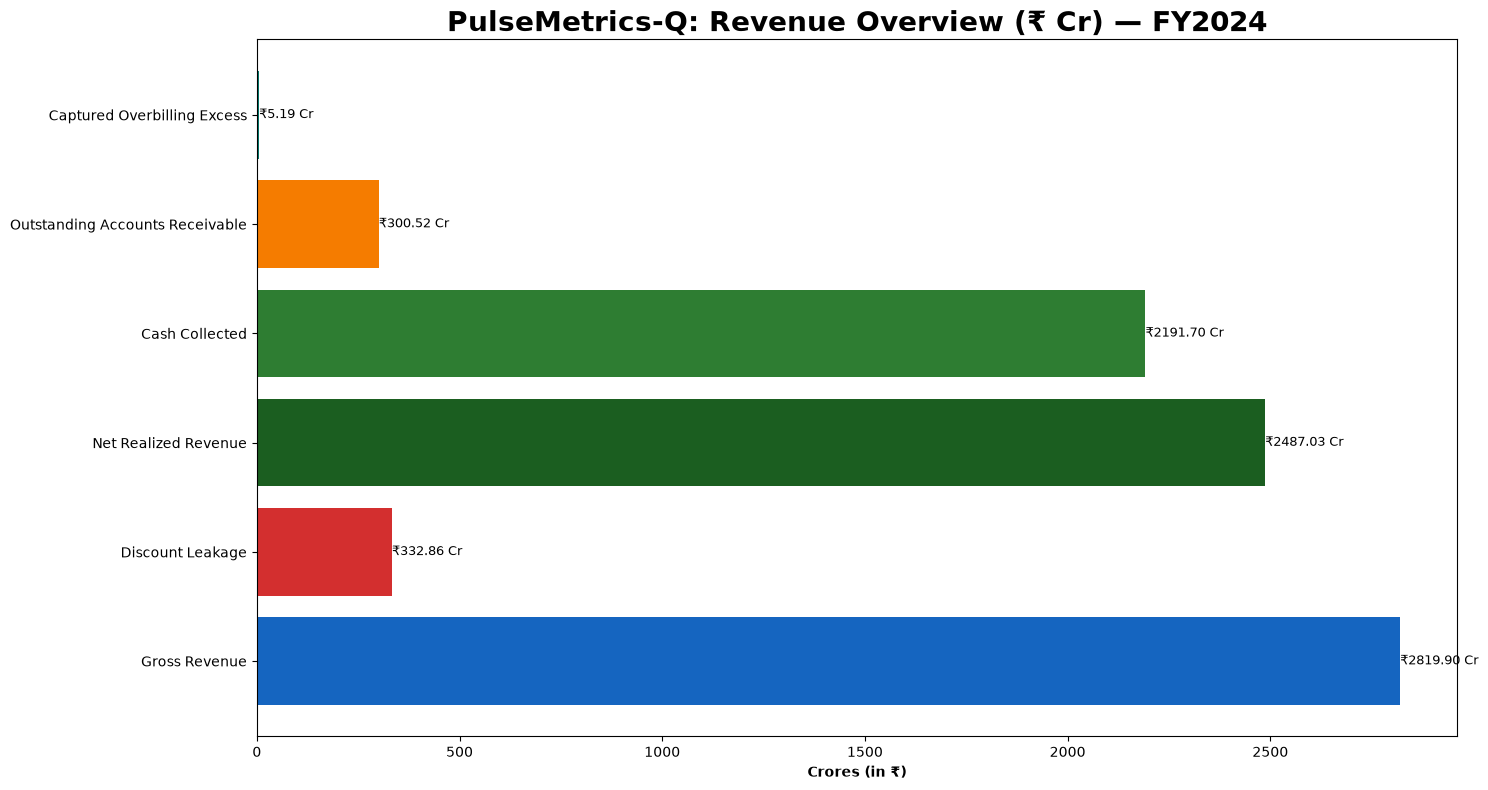

In [216]:
# Figure 00: Chain Key Revenue Indicators (all in Cr metrics)
rev_labels = ['Gross Revenue', 'Discount Leakage', 'Net Realized Revenue', 'Cash Collected', 'Outstanding Accounts Receivable', 'Captured Overbilling Excess']
rev_values = [total_gross_revenue / 1e7, total_discount_amount / 1e7, total_net_revenue / 1e7, total_collected / 1e7, total_outstanding / 1e7, excess_captured / 1e7]
revenue_colors = ["#1565C0", "#D32F2F", "#1B5E20", "#2E7D32", "#F57C00", "#00796B"]

# Simple horizontal bar chart
plt.figure(figsize=(15, 8))
bars = plt.barh(rev_labels, rev_values, color = revenue_colors)
plt.xlabel('Crores (in ₹)', fontsize = 10, fontweight='bold')
plt.title('PulseMetrics-Q: Revenue Overview (₹ Cr) — FY2024', fontsize=20, fontweight='bold')

# Add value labels on each bar
for bar, val in zip(bars, rev_values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'₹{val:.2f} Cr', va='center', fontsize=9)
plt.tight_layout()

# Save the Output as PNG
plt.savefig(output_path + 'figures/00_executive_revenue_indicators.png', dpi=300, bbox_inches='tight')

plt.show()

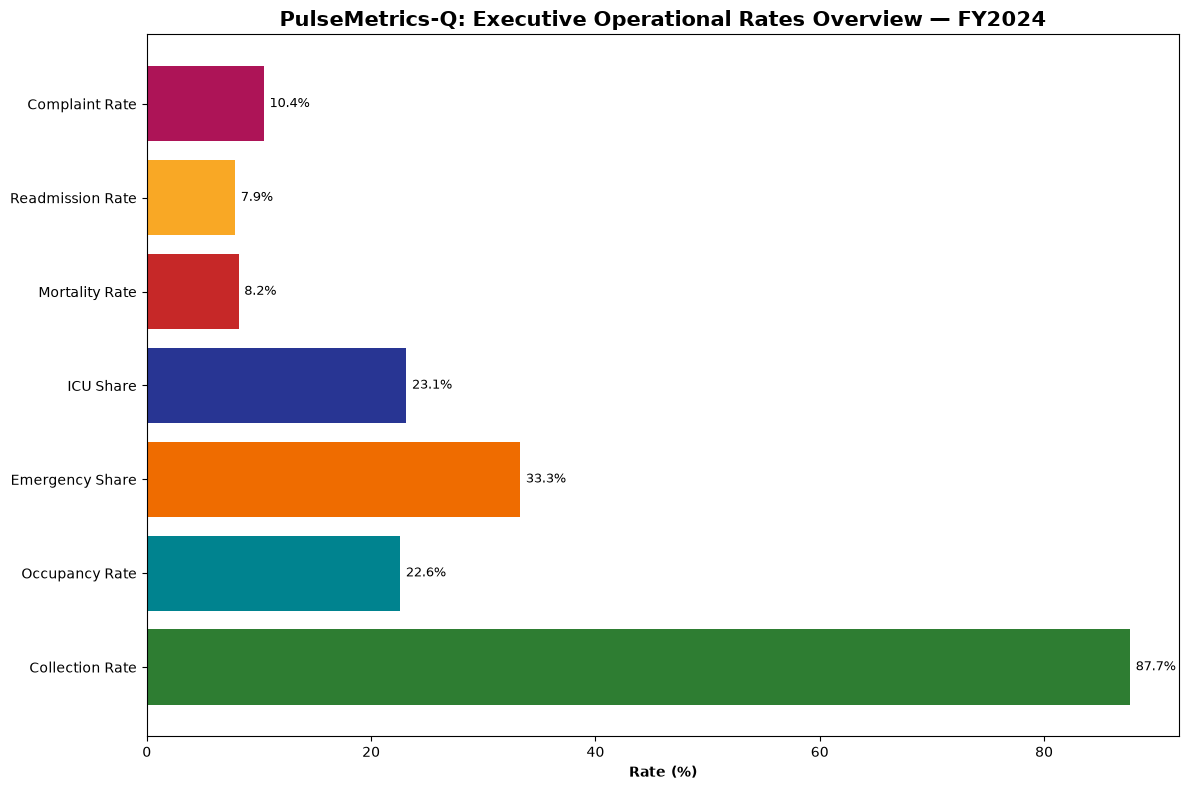

In [218]:
# Figure 01: Chain Key Rate Indicators (all % metrics on same scale)
rate_labels = ['Collection Rate', 'Occupancy Rate', 'Emergency Share', 'ICU Share', 'Mortality Rate', 'Readmission Rate', 'Complaint Rate']
rate_values = [collection_rate, occupancy_rate, emergency_share, icu_share, mortality_rate, readmission_rate, complaint_rate]

# Simple horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(rate_labels, rate_values, color=['#2E7D32', '#00838F', '#EF6C00', '#283593', '#C62828', '#F9A825', '#AD1457'])
plt.xlabel('Rate (%)', fontsize = 10, fontweight='bold')
plt.title('PulseMetrics-Q: Executive Operational Rates Overview — FY2024', fontsize=15, fontweight='bold')

# Add value labels on each bar
for bar, val in zip(bars, rate_values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
# Save the Output as PNG
plt.savefig(output_path + 'figures/01_chain_key_rate_indicators.png', dpi=300, bbox_inches='tight')

plt.show()

#### Branch Scorecard

In [147]:
# Hospital Branch Executive Summary

branch = admission_master.groupby(['hospital_id','hospital_name','hospital_city','region','tier','accreditation']
                                 ).agg( admissions = ('admission_id','count'),
                                        bed_capacity = ('bed_capacity','first'),
                                        total_los = ('length_of_stay','sum'),
                                        alos = ('length_of_stay','mean'),
                                        net_revenue = ('net_amount','sum'),
                                        collected_amount = ('collected_amount','sum'),
                                        readmission_rate = ('readmission_flag', lambda x: x.mean() * 100),
                                        mortality_rate = ('mortality_flag', lambda x: x.mean() * 100),
                                        avg_csat = ('overall_csat', 'mean'),
                                        avg_nps = ('nps_score', 'mean')).reset_index()
branch.head()

,hospital_id,hospital_name,hospital_city,region,tier,accreditation,admissions,bed_capacity,total_los,alos,net_revenue,collected_amount,readmission_rate,mortality_rate,avg_csat,avg_nps
0,1,PulseMetrics Hospital Bengaluru,Bengaluru,South,Tier-1,NABH,8981,650,72863,8.113016,2.606417e+09,2.351707e+09,5.611847,11.134618,4.096804,64.354422
1,2,PulseMetrics Hospital Mumbai,Mumbai,West,Tier-1,JCI,11048,800,94241,8.530141,3.207911e+09,2.894657e+09,5.439899,12.183201,4.246823,65.042174
2,3,PulseMetrics Hospital Delhi,Delhi,North,Tier-1,NABH,10165,720,70998,6.984555,2.364437e+09,2.130349e+09,6.178062,11.431382,3.850105,64.672440
3,4,PulseMetrics Hospital Chennai,Chennai,South,Tier-1,NABH,8455,600,61792,7.308338,2.357410e+09,2.123031e+09,5.251331,9.118865,4.036611,64.657601
4,5,PulseMetrics Hospital Hyderabad,Hyderabad,South,Tier-1,NABH,8018,580,53855,6.716762,2.181413e+09,1.965620e+09,6.909454,9.017211,3.678972,45.456127


In [148]:
branch['occupancy_rate'] = ( branch['total_los'] / (branch['bed_capacity'] * 365)) * 100
branch['arpob'] = (branch['net_revenue'] / branch['total_los']).round(2)
branch['collection_rate'] = (branch['collected_amount'] / branch['net_revenue']) * 100
branch['net_revenue_cr'] = (branch['net_revenue'] / 1e7).round(2)
branch['collected_amount_cr'] = (branch['collected_amount'] / 1e7).round(2)

branch = branch.sort_values(by='net_revenue', ascending=False).reset_index(drop=True)
branch

,hospital_id,hospital_name,hospital_city,region,tier,accreditation,admissions,bed_capacity,total_los,alos,...,collected_amount,readmission_rate,mortality_rate,avg_csat,avg_nps,occupancy_rate,arpob,collection_rate,net_revenue_cr,collected_amount_cr
0,2,PulseMetrics Hospital Mumbai,Mumbai,West,Tier-1,JCI,11048,800,94241,8.530141,...,2.894657e+09,5.439899,12.183201,4.246823,65.042174,32.274315,34039.45,90.234945,320.79,289.47
1,1,PulseMetrics Hospital Bengaluru,Bengaluru,South,Tier-1,NABH,8981,650,72863,8.113016,...,2.351707e+09,5.611847,11.134618,4.096804,64.354422,30.711486,35771.48,90.227555,260.64,235.17
2,3,PulseMetrics Hospital Delhi,Delhi,North,Tier-1,NABH,10165,720,70998,6.984555,...,2.130349e+09,6.178062,11.431382,3.850105,64.672440,27.015982,33302.86,90.099642,236.44,213.03
3,4,PulseMetrics Hospital Chennai,Chennai,South,Tier-1,NABH,8455,600,61792,7.308338,...,2.123031e+09,5.251331,9.118865,4.036611,64.657601,28.215525,38150.74,90.057784,235.74,212.30
4,5,PulseMetrics Hospital Hyderabad,Hyderabad,South,Tier-1,NABH,8018,580,53855,6.716762,...,1.965620e+09,6.909454,9.017211,3.678972,45.456127,25.439301,40505.31,90.107654,218.14,196.56
5,7,PulseMetrics Hospital Kolkata,Kolkata,East,Tier-1,NABH,7129,500,47203,6.621265,...,1.427088e+09,7.728994,10.211811,3.559238,45.207071,25.864658,33566.42,90.069168,158.44,142.71
6,6,PulseMetrics Hospital Pune,Pune,West,Tier-1,NABH,6176,450,35117,5.686043,...,1.419491e+09,7.383420,8.079663,3.711677,44.498799,21.380213,44915.99,89.994152,157.73,141.95
7,8,PulseMetrics Hospital Ahmedabad,Ahmedabad,West,Tier-1,Unaccredited,5752,420,30982,5.386300,...,1.299668e+09,7.632128,7.701669,3.175614,27.810363,20.210046,46597.28,90.024837,144.37,129.97
8,13,PulseMetrics Hospital Kochi,Kochi,South,Tier-2,NABH,4275,310,23773,5.560936,...,5.995641e+08,4.818713,5.660819,3.825485,64.777858,21.010163,30221.28,83.452381,71.85,59.96
9,9,PulseMetrics Hospital Jaipur,Jaipur,North,Tier-2,Unaccredited,4558,320,20948,4.595875,...,4.947892e+08,8.973234,7.591049,3.350066,45.043963,17.934932,28324.07,83.391554,59.33,49.48


In [160]:
display_cols = [
    'hospital_name', 'region', 'tier', 'admissions', 'bed_capacity', 
    'occupancy_rate', 'net_revenue_cr', 'collected_amount_cr', 'arpob', 'alos', 
    'readmission_rate', 'mortality_rate', 'avg_csat', 'avg_nps']

branch_summary = branch[display_cols].copy()
branch_summary.columns = [
    'Hospital Name', 'Region', 'Tier', 'Admissions', 'Beds', 
    'Occupancy %', 'Net Revenue (₹ Cr)', 'Collected Amount (₹ Cr)', 'ARPOB (₹/day)', 'ALOS (days)', 
    'Readmission %', 'Mortality %', 'Avg CSAT', 'Avg NPS']

# Rounding to 2 digits
# branch_summary['Occupancy %'] = branch_summary['Occupancy %'].round(2)
# branch_summary['ALOS (days)'] = branch_summary['ALOS (days)'].round(2)
# branch_summary['Readmission %'] = branch_summary['Readmission %'].round(2)
# branch_summary['Mortality %'] = branch_summary['Mortality %'].round(2)
# branch_summary['Avg CSAT'] = branch_summary['Avg CSAT'].round(2)
# branch_summary['Avg NPS'] = branch_summary['Avg NPS'].round(2)

branch_summary = branch_summary.round({"Occupancy %": 2, "ALOS (days)": 2, "Readmission %": 2, "Mortality %": 2, "Avg CSAT": 2, "Avg NPS": 2})


branch_summary

,Hospital Name,Region,Tier,Admissions,Beds,Occupancy %,Net Revenue (₹ Cr),Collected Amount (₹ Cr),ARPOB (₹/day),ALOS (days),Readmission %,Mortality %,Avg CSAT,Avg NPS
0,PulseMetrics Hospital Mumbai,West,Tier-1,11048,800,32.27,320.79,289.47,34039.45,8.53,5.44,12.18,4.25,65.04
1,PulseMetrics Hospital Bengaluru,South,Tier-1,8981,650,30.71,260.64,235.17,35771.48,8.11,5.61,11.13,4.10,64.35
2,PulseMetrics Hospital Delhi,North,Tier-1,10165,720,27.02,236.44,213.03,33302.86,6.98,6.18,11.43,3.85,64.67
3,PulseMetrics Hospital Chennai,South,Tier-1,8455,600,28.22,235.74,212.30,38150.74,7.31,5.25,9.12,4.04,64.66
4,PulseMetrics Hospital Hyderabad,South,Tier-1,8018,580,25.44,218.14,196.56,40505.31,6.72,6.91,9.02,3.68,45.46
5,PulseMetrics Hospital Kolkata,East,Tier-1,7129,500,25.86,158.44,142.71,33566.42,6.62,7.73,10.21,3.56,45.21
6,PulseMetrics Hospital Pune,West,Tier-1,6176,450,21.38,157.73,141.95,44915.99,5.69,7.38,8.08,3.71,44.50
7,PulseMetrics Hospital Ahmedabad,West,Tier-1,5752,420,20.21,144.37,129.97,46597.28,5.39,7.63,7.70,3.18,27.81
8,PulseMetrics Hospital Kochi,South,Tier-2,4275,310,21.01,71.85,59.96,30221.28,5.56,4.82,5.66,3.83,64.78
9,PulseMetrics Hospital Jaipur,North,Tier-2,4558,320,17.93,59.33,49.48,28324.07,4.60,8.97,7.59,3.35,45.04


In [217]:
# Report 01: Branch Executive League Table
branch_summary.to_csv(output_path + 'reports/01_hospital_branch_summary_table.csv', index=False, encoding='utf-8-sig')

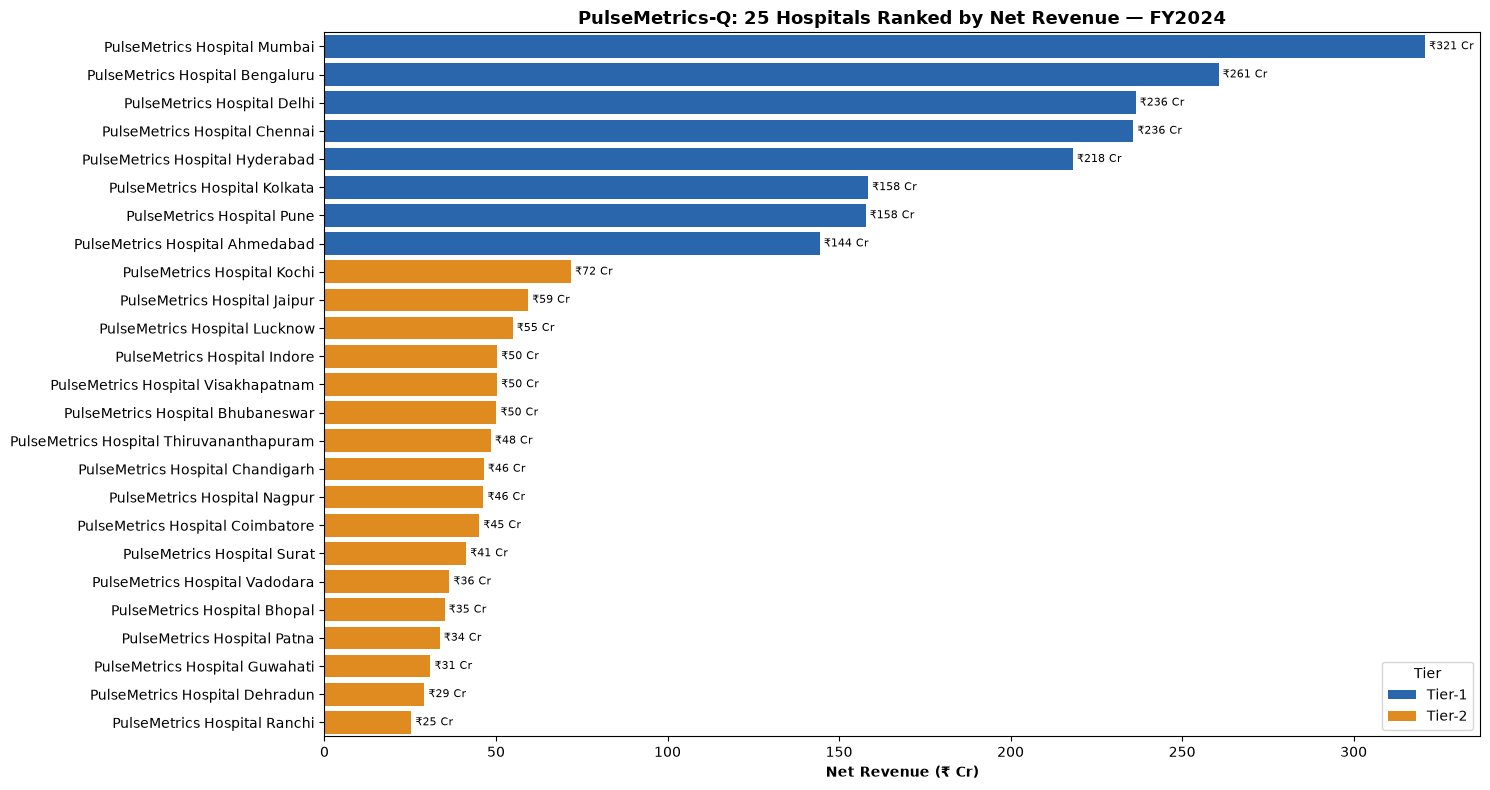

In [222]:
# Figure 02: 25 Hospitals Ranked by Net Revenue
plt.figure(figsize=(15,8))
sns.barplot( data = branch_summary, x = 'Net Revenue (₹ Cr)', y = 'Hospital Name', hue = 'Tier', dodge = False, palette={'Tier-1': '#1565C0', 'Tier-2': '#FF8F00'})

# Add data labels
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='₹%.0f Cr', padding=3, fontsize=8)
plt.title('PulseMetrics-Q: 25 Hospitals Ranked by Net Revenue — FY2024', fontsize=13, fontweight='bold')
plt.xlabel('Net Revenue (₹ Cr)', fontsize=10, fontweight='bold')
plt.ylabel('')
plt.legend(title='Tier')
plt.tight_layout()

# Save in PNG
plt.savefig(output_path + 'figures/02_branch_revenue_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Monthly Revenue & Admissions Summary

monthly_rev = admission_master.groupby(['month','month_name']).agg(admissions = ('admission_id', 'count'),
                                                                   gross_revenue = ('gross_amount', 'sum'),
                                                                   discount_amount = ('discount_amount', 'sum'),
                                                                   net_revenue = ('net_amount', 'sum'),
                                                                   collected_amount = ('collected_amount', 'sum'),
                                                                   arpa = ('net_amount', 'mean'),
                                                                   alos = ('length_of_stay', 'mean')).reset_index()

# Convert revenues to ₹ Cr

monthly_rev['gross_revenue'] = monthly_rev['gross_revenue'] / 1e7
monthly_rev['net_revenue'] = monthly_rev['net_revenue'] / 1e7
monthly_rev['discount_amount'] = monthly_rev['discount_amount'] / 1e7
monthly_rev['collected_amount'] = monthly_rev['collected_amount'] / 1e7
monthly_rev['discount_rate_%'] = ((monthly_rev['discount_amount'] / monthly_rev['gross_revenue']) * 100).round(2)

monthly_rev

In [ ]:
# Calculate Month-over-Month (MoM) Revenue Growth %

monthly_rev['mom_growth%'] = (monthly_rev['net_revenue'].pct_change() * 100).round(2).fillna(0)

monthly_rev